# Vanguard / WISER 2026 — Presentation Benchmark Suite

This notebook tests a constraint-safe hybrid portfolio solver. The classical
factor model handles the full asset universe; classical LNS and
cardinality-preserving XY-QAOA propose changes inside the same small adaptive
window; an exact continuous allocation oracle assigns weights; and an
independent validator decides whether a candidate may be reported.

The evaluation evidence:

1. exact correctness on a tractable instance;
2. simultaneous enforcement of every financial guardrail;
3. candidate quality and cost for classical and quantum window search;
4. factor-native speed and memory scaling with a fixed quantum workload;
5. optional IBM hardware validation with job IDs and physical-circuit metrics.

The notebook demonstrates how a quantum candidate generator can augment 
a scalable classical optimizer while every final portfolio remains 
conventionally allocated and independently validated.


## Execution order and cost profile

Run cells from top to bottom after installing the unified environment and
restarting the kernel:

```bash
python -m pip install -e ".[full]"
python scripts/install_environment.py --verify-only
```

Default experiments are sized for a strong workstation and avoid
open-ended solver calls. The repeated global core ends at 300,000 assets;
300,000–500,000 asset points are an explicit opt-in stretch test.

Each section states its question, method, and evaluator-facing output before
any code runs. Stale outputs are intentionally removed from the committed
notebook so results always describe the current machine and commit.


In [1]:
# Run before importing NumPy/SciPy in a fresh kernel.
import gc
import os
from pathlib import Path

NUMERICAL_THREADS = min(16, os.cpu_count() or 1)
for variable in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ.setdefault(variable, str(NUMERICAL_THREADS))

def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (
            (candidate / "pyproject.toml").is_file()
            and (candidate / "src" / "vanguard_portfolio").is_dir()
        ):
            return candidate.resolve()
    raise FileNotFoundError("Run from the repository or notebooks/ directory.")

REPO = find_repo_root()
os.chdir(REPO)

# ---------- Master switches ----------
RUN_PYTEST = False
RUN_CONTINUOUS_BACKEND_CROSSCHECK = True
RUN_TINY_CERTIFICATION = True
RUN_MAIN_100_ASSET_CASE = True
RUN_GUROBI_WARM_START_STUDY = True
RUN_BACKTEST_ROBUSTNESS = True
RUN_ALL_CONSTRAINTS_GAUNTLET = True
RUN_CONSTRAINT_ABLATION = True

RUN_FROZEN_WINDOW_BENCHMARK = True
RUN_WIDTH_DEPTH_SWEEP = True
RUN_AER_BACKEND_COMPARISON = True

RUN_SCALING_PRESENTATION = True
RUN_SCALING_STRETCH = False

# Hardware jobs require an IBM account and may consume paid allocation.
# Keep False for a complete local run; the QPU cell prints one-time setup.
RUN_IBM_QPU = True
QPU_RESUME = True
QPU_FAIL_FAST = False
RUN_LEGACY_ALTERNATIVE_MODELS = True

OVERWRITE_OUTPUTS = True
BASE_SEED = 20260802
EXPECTED_BRANCH = "research/benchmark-notebook-cleanup"
OUTPUT_ROOT = REPO / "results" / "presentation_benchmark_suite"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ---------- Full-constraint experiment ----------
GAUNTLET_SCENARIO_COUNTS = (500, 2_000, 10_000, 50_000, 100_000)
GAUNTLET_SCENARIO_REPETITIONS = 3
GAUNTLET_SCALING_BACKENDS = ("osqp", "clarabel")
RUN_GAUNTLET_HYBRID_STRESS = True
GAUNTLET_HYBRID_STRESS_SCENARIOS = 10_000

# ---------- Explicit classical solver controls ----------
ALLOCATION_BACKEND = "osqp"
QP_TOLERANCE = 1.0e-9
QP_MAX_ITERATIONS = 250_000
GUIDE_TIME_LIMIT_SECONDS = 30.0
ALLOW_GUIDE_FALLBACK = True
USE_GUROBI = True
GUROBI_TIME_LIMIT_SMALL = 120.0
GUROBI_TIME_LIMIT_MAIN = 300.0
GUROBI_MIP_GAP = 1.0e-3
BACKTEST_ROBUSTNESS_PATHS = 30
BACKTEST_PERIODS = 120

# ---------- Quantum candidate generation ----------
LOCAL_QUANTUM_BACKEND_REQUEST = "aer_gpu"
QAOA_DEPTH = 1
QAOA_SHOTS = 2_048
QAOA_OPTIMIZER_MAXITER = 60
QAOA_OPTIMIZER_STARTS = 3
QAOA_TOP_CANDIDATES = 32
QAOA_MAX_SUBSPACE_STATES = 400_000
QAOA_MAX_EDGES = 40
TRANSPILE_OPTIMIZATION_LEVEL = 3

# ---------- Controlled window study ----------
FROZEN_WINDOW_ASSETS = 250
FROZEN_PORTFOLIO_K = 50
FROZEN_WINDOW_WIDTH = 16
EXACT_QUBO_MAX_STATES = 3_000_000
EXACT_QUBO_TOP_K = 128
RANDOM_CANDIDATE_BUDGET = 128
WIDTH_SWEEP = [8, 10, 12, 14, 16, 18, 20, 22, 24]
DEPTH_SWEEP_WIDTHS = [10, 12, 14, 16]
DEPTH_SWEEP = [1, 2]
SWEEP_BACKEND = "subspace"
SWEEP_MAX_SUBSPACE_STATES = 2_500_000

# ---------- Global factor-native scaling ----------
GLOBAL_CORE_SIZES = [1_000, 10_000, 20_000, 50_000, 80_000, 100_000, 150_000, 200_000, 300_000]
GLOBAL_STRETCH_SIZES = [400_000, 500_000]
SCALING_REPETITIONS = 3
SCALING_STRETCH_REPETITIONS = 1
SCALING_CASE_TIME_LIMIT = 180.0
SCALING_WINDOW_SIZE = 16
SCALING_CARDINALITY = 50

# ---------- IBM Runtime ----------
IBM_BACKEND_NAME = "ibm_fez"
QPU_WIDTHS = [8, 10, 12]
QPU_DEPTHS = [1]
QPU_REPETITIONS = 2
QPU_SHOTS = 4_096
QPU_MAX_EDGES = 30
QPU_OPTIMIZER_MAXITER = 100
QPU_OPTIMIZER_STARTS = 5

print("Repository:", REPO)
print("Output root:", OUTPUT_ROOT)
print("Numerical threads:", NUMERICAL_THREADS)


Repository: /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio
Output root: /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/results/presentation_benchmark_suite
Numerical threads: 16


## 1. Environment and accelerator preflight

**Experiment.** Records the exact commit, Python packages, CPU, memory,
NVIDIA inventory, and real Aer CPU/GPU execution probes.

**Importance.** Timings are meaningful only with reproducible
hardware/software context. A GPU is selected only after a real CUDA circuit
succeeds; its role is Aer circuit sampling, not the OSQP factor solve. IBM
Runtime is checked in the same environment but credentials are never stored
in the notebook.


In [2]:
import json
import platform
import subprocess
import sys
from datetime import datetime, timezone
from importlib import metadata


def command_output(command: list[str], timeout: int = 30) -> str:
    completed = subprocess.run(
        command,
        cwd=REPO,
        text=True,
        capture_output=True,
        timeout=timeout,
        check=False,
    )
    return (completed.stdout or completed.stderr).strip()

environment = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "branch": command_output(["git", "branch", "--show-current"]),
    "commit": command_output(["git", "rev-parse", "HEAD"]),
    "status": command_output(["git", "status", "--short"]),
    "cpu": command_output(["bash", "-lc", "lscpu | sed -n '1,25p'"]),
    "memory": command_output(["free", "-h"]),
    "gpu": command_output(["nvidia-smi"]),
}

package_names = [
    "numpy", "scipy", "pandas", "matplotlib", "osqp", "gurobipy",
    "qiskit", "qiskit-aer", "qiskit-aer-gpu",
    "qiskit-aer-gpu-cu11", "qiskit-ibm-runtime",
]
environment["packages"] = {}
for name in package_names:
    try:
        environment["packages"][name] = metadata.version(name)
    except metadata.PackageNotFoundError:
        pass

aer_devices = ()
aer_advertised_devices = ()
try:
    from qiskit import QuantumCircuit, transpile
    from qiskit_aer import AerSimulator

    aer_advertised_devices = tuple(AerSimulator().available_devices())

    def verify_aer_device(device: str) -> None:
        simulator = AerSimulator(method="statevector", device=device)
        circuit = QuantumCircuit(2)
        circuit.h(0)
        circuit.cx(0, 1)
        circuit.measure_all()
        compiled = transpile(circuit, simulator, optimization_level=0)
        result = simulator.run(
            compiled,
            shots=32,
            seed_simulator=BASE_SEED,
        ).result()
        if not bool(getattr(result, "success", True)):
            raise RuntimeError(getattr(result, "status", "unknown status"))

    verified_devices = []
    verify_aer_device("CPU")
    verified_devices.append("CPU")
    if "GPU" in aer_advertised_devices:
        try:
            verify_aer_device("GPU")
            verified_devices.append("GPU")
        except Exception as exc:  # noqa: BLE001 - optional GPU probe
            environment["aer_gpu_probe_error"] = (
                f"{type(exc).__name__}: {exc}"
            )
    aer_devices = tuple(verified_devices)
except Exception as exc:  # noqa: BLE001 - optional Aer import
    environment["aer_import_error"] = f"{type(exc).__name__}: {exc}"
environment["aer_advertised_devices"] = list(aer_advertised_devices)
environment["aer_devices"] = list(aer_devices)

installed_aer_distributions = [
    name
    for name in (
        "qiskit-aer",
        "qiskit-aer-gpu",
        "qiskit-aer-gpu-cu11",
    )
    if name in environment["packages"]
]
environment["installed_aer_distributions"] = installed_aer_distributions

if RUN_IBM_QPU:
    expected_versions = {
        "qiskit": "2.5.1",
        "qiskit-ibm-runtime": "0.48.0",
    }
    version_mismatches = {
        name: {
            "expected": expected,
            "installed": environment["packages"].get(name),
        }
        for name, expected in expected_versions.items()
        if environment["packages"].get(name) != expected
    }
    if len(installed_aer_distributions) != 1:
        raise RuntimeError(
            "The QPU notebook requires exactly one Aer distribution, but "
            f"found {installed_aer_distributions}. Run "
            f"{sys.executable} scripts/install_environment.py, then restart "
            "this kernel."
        )
    if version_mismatches:
        raise RuntimeError(
            "The notebook kernel is not using the pinned unified quantum "
            f"stack: {version_mismatches}. Interpreter: {sys.executable}"
        )
    try:
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    except Exception as exc:
        raise RuntimeError(
            "IBM Runtime cannot import in this notebook kernel. Run "
            f"{sys.executable} -m pip install -e '.[full]' from the repository, "
            "restart the kernel, and rerun the preflight."
        ) from exc
    environment["ibm_runtime_import"] = (
        f"ok: {QiskitRuntimeService.__name__}, {SamplerV2.__name__}"
    )

gurobi_available = False
try:
    import gurobipy as gp
    probe = gp.Model()
    probe.Params.OutputFlag = 0
    gurobi_available = True
    environment["gurobi_version"] = ".".join(map(str, gp.gurobi.version()))
except Exception as exc:  # noqa: BLE001 - optional licensed backend
    environment["gurobi_error"] = f"{type(exc).__name__}: {exc}"
environment["gurobi_available"] = gurobi_available

if environment["branch"] != EXPECTED_BRANCH:
    print(
        f"WARNING: expected {EXPECTED_BRANCH!r}; "
        f"found {environment['branch']!r}. Results remain tagged with the actual commit."
    )

LOCAL_QUANTUM_BACKEND = (
    "aer_gpu"
    if LOCAL_QUANTUM_BACKEND_REQUEST == "aer_gpu" and "GPU" in aer_devices
    else "subspace"
)
if LOCAL_QUANTUM_BACKEND_REQUEST == "aer_gpu" and LOCAL_QUANTUM_BACKEND != "aer_gpu":
    print("WARNING: Aer GPU unavailable; local quantum tests use subspace.")

(OUTPUT_ROOT / "environment.json").write_text(
    json.dumps(environment, indent=2) + "\n",
    encoding="utf-8",
)
print(json.dumps(environment, indent=2))
print("Resolved local quantum backend:", LOCAL_QUANTUM_BACKEND)
print("Gurobi enabled:", bool(USE_GUROBI and gurobi_available))

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2845661
Academic license 2845661 - for non-commercial use only - registered to ap___@usf.edu
{
  "timestamp_utc": "2026-08-06T16:18:07.212928+00:00",
  "python": "3.10.20 (main, Jun 11 2026, 15:17:37) [GCC 14.3.0]",
  "platform": "Linux-6.1.0-34-amd64-x86_64-with-glibc2.36",
  "branch": "research/benchmark-notebook-cleanup",
  "commit": "4f614304b3191ef4ea51e4f6eebf93bab8101532",
  "status": "M notebooks/Vanguard_Presentation_Benchmark_Suite.ipynb\n M scripts/run_hybrid_scaling.py",
  "cpu": "Architecture:                         x86_64\nCPU op-mode(s):                       32-bit, 64-bit\nAddress sizes:                        48 bits physical, 48 bits virtual\nByte Order:                           Little Endian\nCPU(s):                               32\nOn-line CPU(s) list:                  0-31\nVendor ID:                            AuthenticAMD\nModel name:                           AMD Ryzen 9 5950X

## 2. Shared model, validation, and compact artifact helpers

**Experiment.** Imports the solver once and defines consistent result
tables, canonical CVaR evaluation, support comparisons, and an
evaluator-facing artifact profile.

**Importance.** Every experiment uses the same objective,
fixed-support allocation oracle, and independent validator. The compact
profile avoids dozens of redundant plots while retaining auditable CSV/JSON
evidence and the few figures used in the presentation.


In [3]:
import importlib.util
import shutil
import time
from dataclasses import replace
from math import comb

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage
from IPython.display import display

SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from vanguard_portfolio.allocation import (
    AllocationOracle,
    find_feasible_initial_support,
    solve_relaxation,
)
from vanguard_portfolio.classical_continuous import solve_continuous
from vanguard_portfolio.classical_discrete import solve_cardinality_gurobi
from vanguard_portfolio.data_generation import (
    generate_backtest_returns,
    generate_factor_universe,
    generate_return_scenarios,
    generate_synthetic_universe,
)
from vanguard_portfolio.hybrid import HybridConfig, HybridRun, run_hybrid_optimizer
from vanguard_portfolio.portfolio_model import empirical_cvar as canonical_empirical_cvar
from vanguard_portfolio.presentation import write_hybrid_artifacts
from vanguard_portfolio.quantum_solver import (
    XYQAOAConfig,
    _basis_energies,
    _fixed_weight_basis,
    solve_xy_qaoa,
)
from vanguard_portfolio.qubo_builder import build_window_qubo
from vanguard_portfolio.schemas import PortfolioConstraints, PortfolioProblem, Preferences
from vanguard_portfolio.topology import market_communities
from vanguard_portfolio.validation import validate_weights
from vanguard_portfolio.window_search import (
    construct_change_window,
    current_window_bits,
    evaluate_bitstrings,
    tabu_window_search,
)

PREFERENCES = Preferences(
    lambda_return=1.0,
    lambda_risk=5.0,
    lambda_income=0.5,
    lambda_cost=1.0,
)

def clean_directory(path: Path) -> None:
    if path.exists() and OVERWRITE_OUTPUTS:
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def result_table(run: HybridRun) -> pd.DataFrame:
    frame = pd.DataFrame(run.summary_records())
    columns = [
        "method", "stage", "iteration", "objective", "runtime_seconds",
        "feasible", "breaches", "max_violation", "support_size",
        "expected_return", "volatility", "income", "turnover",
        "best_bound", "reported_mip_gap",
    ]
    return frame[[column for column in columns if column in frame.columns]]

def run_and_archive(
    label: str,
    problem: PortfolioProblem,
    constraints: PortfolioConstraints,
    config: HybridConfig,
    *,
    backtest_periods: int = 120,
    backtest_seed: int = BASE_SEED + 1,
) -> tuple[HybridRun, pd.DataFrame, Path]:
    output = OUTPUT_ROOT / label
    clean_directory(output)
    total_start = time.perf_counter()
    run = run_hybrid_optimizer(problem, PREFERENCES, constraints, config)
    realized = generate_backtest_returns(
        problem,
        periods=backtest_periods,
        periods_per_year=12,
        seed=backtest_seed,
    )
    write_hybrid_artifacts(
        run, output, realized_returns=realized, profile="evaluation"
    )
    frame = result_table(run)
    frame.to_csv(output / "notebook_method_summary.csv", index=False)
    (output / "notebook_wall_seconds.txt").write_text(
        f"{time.perf_counter() - total_start:.9f}\n",
        encoding="utf-8",
    )
    print(
        f"{label}: best={run.best.method}, objective={run.best.objective:.10g}, "
        f"breaches={run.best.breaches}, runtime={run.runtime:.3f}s"
    )
    display(frame)
    return run, frame, output

def empirical_cvar(
    scenario_returns: np.ndarray,
    weights: np.ndarray,
    alpha: float = 0.95,
) -> float:
    # Keep calibration and independent validation on the same finite-sample
    # Rockafellar–Uryasev definition used by the solver.
    return canonical_empirical_cvar(weights, scenario_returns, alpha)

def support(weights: np.ndarray, tolerance: float = 1.0e-8) -> set[int]:
    return set(np.flatnonzero(np.asarray(weights) > tolerance).tolist())

def support_jaccard(left: np.ndarray, right: np.ndarray) -> float:
    a, b = support(left), support(right)
    return len(a & b) / max(len(a | b), 1)

def best_by_method(run: HybridRun) -> dict[str, object]:
    selected = {}
    for result in run.all_results():
        if not (result.success and result.feasible):
            continue
        previous = selected.get(result.method)
        if previous is None or result.objective < previous.objective:
            selected[result.method] = result
    return selected

def plot_top_trades(run: HybridRun, output: Path, count: int = 10) -> Path:
    change = run.best.weights - run.problem.w0
    buys = np.argsort(change)[-count:][::-1]
    sells = np.argsort(change)[:count]
    indices = np.concatenate([sells, buys])
    figure, axis = plt.subplots(figsize=(12, 5))
    axis.bar(np.arange(len(indices)), change[indices])
    axis.axhline(0.0, linewidth=1.0)
    axis.set_xticks(np.arange(len(indices)))
    axis.set_xticklabels(
        [run.problem.asset_names[index] for index in indices],
        rotation=55,
        ha="right",
    )
    axis.set_ylabel("Recommended weight minus current weight")
    axis.set_title("Largest recommended sales and purchases")
    figure.tight_layout()
    path = output / "top_trades.png"
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path

def plot_support_overlap(run: HybridRun, output: Path) -> Path:
    methods = best_by_method(run)
    names = list(methods)
    matrix = np.empty((len(names), len(names)))
    for i, left in enumerate(names):
        for j, right in enumerate(names):
            matrix[i, j] = support_jaccard(
                methods[left].weights,
                methods[right].weights,
            )
    figure, axis = plt.subplots(figsize=(8, 7))
    image = axis.imshow(matrix, vmin=0.0, vmax=1.0)
    axis.set_xticks(range(len(names)))
    axis.set_yticks(range(len(names)))
    axis.set_xticklabels(names, rotation=55, ha="right")
    axis.set_yticklabels(names)
    for i in range(len(names)):
        for j in range(len(names)):
            axis.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")
    axis.set_title("Support overlap (Jaccard similarity)")
    figure.colorbar(image, ax=axis)
    figure.tight_layout()
    path = output / "support_overlap.png"
    figure.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    return path

## 3. Repository test suite

**Experiment.** Runs the project tests before any benchmark evidence is
generated. 

**Importance.** A fast figure is irrelevant if model,
validation, packaging, or backend regression tests fail.


In [4]:
if RUN_PYTEST:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "-q"],
        cwd=REPO,
        check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError("The test suite failed; stop before generating claims.")

## 3A. Continuous-backend agreement

**Experiment.** Solves the same convex portfolio with available SciPy,
OSQP, Clarabel, and Gurobi backends. 

**Importance.** Agreement in
objective and feasibility makes the faster native sparse backends credible;
the output is one comparison table.


In [5]:
continuous_backend_crosscheck = None

if RUN_CONTINUOUS_BACKEND_CROSSCHECK:
    cross_problem = generate_factor_universe(
        n_assets=100,
        n_groups=8,
        n_factors=6,
        seed=BASE_SEED + 11,
        current_cardinality=None,
        materialize_covariance=False,
    )
    cross_problem.target_return = None
    cross_problem.max_turnover = None

    backend_specs = [
        ("scipy", {"tol": 1.0e-10, "max_iter": 5_000}),
        (
            "osqp",
            {
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
            },
        ),
        ("cvxpy:CLARABEL", {"solver_options": {}}),
    ]
    if USE_GUROBI and gurobi_available:
        backend_specs.append(
            (
                "gurobi",
                {
                    "threads": NUMERICAL_THREADS,
                    "seed": BASE_SEED,
                    "method": 2,
                    "bar_conv_tol": 1.0e-10,
                    "output": False,
                },
            )
        )

    rows = []
    weights_by_backend = {}
    for backend, options in backend_specs:
        try:
            result = solve_continuous(
                cross_problem,
                PREFERENCES,
                backend=backend,
                **options,
            )
            rows.append(
                {
                    "backend": backend,
                    "method": result.method,
                    "status": result.status,
                    "success": result.success,
                    "feasible": result.feasible,
                    "objective": result.objective,
                    "runtime_seconds": result.runtime,
                    "breaches": result.breaches,
                    "max_violation": result.max_violation,
                    "iterations": result.metadata.get("iterations"),
                }
            )
            if result.success and result.feasible:
                weights_by_backend[backend] = result.weights.copy()
        except Exception as exc:  # noqa: BLE001 - backend cross-check row
            rows.append(
                {
                    "backend": backend,
                    "status": "unavailable_or_failed",
                    "success": False,
                    "feasible": False,
                    "error": f"{type(exc).__name__}: {exc}",
                }
            )

    continuous_backend_crosscheck = pd.DataFrame(rows)
    display(continuous_backend_crosscheck)
    continuous_backend_crosscheck.to_csv(
        OUTPUT_ROOT / "continuous_backend_crosscheck.csv",
        index=False,
    )

    successful_rows = continuous_backend_crosscheck[
        continuous_backend_crosscheck["success"] == True
    ]
    if len(successful_rows) >= 2:
        objective_spread = (
            successful_rows["objective"].max()
            - successful_rows["objective"].min()
        )
        pairwise_weight_differences = []
        names = list(weights_by_backend)
        for left_index, left in enumerate(names):
            for right in names[left_index + 1 :]:
                pairwise_weight_differences.append(
                    {
                        "left": left,
                        "right": right,
                        "maximum_absolute_weight_difference": float(
                            np.max(
                                np.abs(
                                    weights_by_backend[left]
                                    - weights_by_backend[right]
                                )
                            )
                        ),
                    }
                )
        print("Objective spread:", objective_spread)
        display(pd.DataFrame(pairwise_weight_differences))

,backend,method,status,success,feasible,objective,runtime_seconds,breaches,max_violation,iterations
0,scipy,scipy_slsqp,Optimization terminated successfully,True,True,-0.049141,1.478604,0,2.220446e-16,61.0
1,osqp,osqp,solved,True,True,-0.049141,0.004036,0,5.838211e-10,275.0
2,cvxpy:CLARABEL,cvxpy_clarabel,optimal,True,True,-0.049141,0.010866,0,2.220446e-16,10.0
3,gurobi,gurobi_qp,optimal,True,True,-0.049141,0.021755,0,7.257817e-11,0.0


Objective spread: 1.4062591646712974e-09


,left,right,maximum_absolute_weight_difference
0,scipy,osqp,0.000045
1,scipy,cvxpy:CLARABEL,0.000168
2,scipy,gurobi,0.000055
3,osqp,cvxpy:CLARABEL,0.000160
4,osqp,gurobi,0.000013
5,cvxpy:CLARABEL,gurobi,0.000146


## 4. Experiment A — tiny exact correctness certificate

**Experiment.** Exhaustively enumerates a tractable exact-K window and,
when licensed, compares it with Gurobi and XY-QAOA proposals. 

**Importance.** This is a genuine correctness certificate: enumeration
and MIQP should agree, and every candidate is independently validated.


In [6]:
tiny_run = tiny_frame = tiny_output = None

if RUN_TINY_CERTIFICATION:
    tiny_problem = generate_synthetic_universe()
    tiny_problem.target_return = None
    tiny_problem.max_turnover = 0.80

    tiny_constraints = PortfolioConstraints(
        exact_cardinality=4,
        minimum_active_weight=0.05,
        maximum_weights=np.minimum(tiny_problem.upper, 0.50),
    ).validate_for(tiny_problem)

    tiny_config = HybridConfig(
        iterations=1,
        window_size=6,
        held_fraction=0.50,
        allocation_backend="scipy",
        allocation_options={"tol": QP_TOLERANCE, "max_iter": 5_000},
        relaxation_options={"tol": QP_TOLERANCE, "max_iter": 5_000},
        initial_trials=300,
        initial_milp_time_limit=20.0,
        classical_tabu_iterations=60,
        classical_tabu_tenure=7,
        classical_oracle_candidates=4,
        enumerate_windows_up_to=100_000,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=1,
            shots=QAOA_SHOTS,
            optimizer_maxiter=120,
            optimizer_starts=6,
            seed=BASE_SEED,
            initial_state="warm",
            mixer="ring",
            backend="subspace",
            maximum_subspace_states=400_000,
            top_candidates=128,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=True,
        penalty_multiplier=10.0,
        use_topology=False,
        maximum_quantum_edges=None,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_SMALL,
        gurobi_mip_gap=1.0e-6,
        seed=BASE_SEED,
    )

    tiny_run, tiny_frame, tiny_output = run_and_archive(
        "01_tiny_exact_certification",
        tiny_problem,
        tiny_constraints,
        tiny_config,
        backtest_periods=60,
    )

    exact_rows = tiny_frame[
        tiny_frame["method"].isin(
            ["classical_enumeration", "gurobi_cardinality_miqp"]
        )
    ]
    if len(exact_rows) >= 2:
        print(
            "Enumeration/Gurobi objective spread:",
            exact_rows["objective"].max() - exact_rows["objective"].min(),
        )

01_tiny_exact_certification: best=feasible_initial_portfolio, objective=-0.03681145, breaches=0, runtime=0.118s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,scipy_slsqp,,,-0.038073,0.009140,True,0,5.551115e-17,5,0.04223,0.061072,0.030111,0.5,,
1,feasible_initial_portfolio,initialization,,-0.036811,0.006825,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
2,classical_enumeration,window_search,0,-0.036811,0.076140,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
3,penalty_qaoa_statevector,window_search,0,-0.036811,0.005432,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,,
4,gurobi_cardinality_miqp,global_certification,1,-0.036811,0.010101,True,0,1.110223e-16,4,0.04350,0.065404,0.031000,0.7,-0.036811,0.0


Enumeration/Gurobi objective spread: 0.0


## 5. Experiment B — canonical 100-asset hybrid portfolio

**Experiment.** Runs the complete factor-relaxation → feasible support →
classical/XY-QAOA window → exact allocation → validation pipeline on a
readable business-sized case. 

**Importance.** It shows the
recommended trades, guardrails, objective quality, and quantum contribution
in one representative run rather than a synthetic micro-benchmark.


In [7]:
main_run = main_frame = main_output = None

if RUN_MAIN_100_ASSET_CASE:
    main_problem = generate_factor_universe(
        n_assets=100,
        n_groups=8,
        n_factors=6,
        seed=BASE_SEED,
        current_cardinality=20,
        materialize_covariance=False,
    )
    main_problem.target_return = None
    main_problem.max_turnover = 0.40

    main_constraints = PortfolioConstraints(
        exact_cardinality=20,
        minimum_active_weight=0.01,
        maximum_weights=np.full(main_problem.n, 0.10),
    ).validate_for(main_problem)

    main_config = HybridConfig(
        iterations=2,
        window_size=16,
        held_fraction=0.45,
        allocation_backend=ALLOCATION_BACKEND,
        allocation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
        relaxation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
        initial_trials=400,
        initial_milp_time_limit=30.0,
        classical_tabu_iterations=80,
        classical_tabu_tenure=8,
        classical_oracle_candidates=4,
        enumerate_windows_up_to=5_000,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=QAOA_DEPTH,
            shots=QAOA_SHOTS,
            optimizer_maxiter=QAOA_OPTIMIZER_MAXITER,
            optimizer_starts=QAOA_OPTIMIZER_STARTS,
            seed=BASE_SEED,
            initial_state="warm",
            mixer="ring",
            backend=LOCAL_QUANTUM_BACKEND,
            maximum_subspace_states=QAOA_MAX_SUBSPACE_STATES,
            top_candidates=QAOA_TOP_CANDIDATES,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=True,
        penalty_multiplier=10.0,
        use_topology=True,
        maximum_quantum_edges=QAOA_MAX_EDGES,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_MAIN,
        gurobi_mip_gap=GUROBI_MIP_GAP,
        seed=BASE_SEED,
    )

    main_run, main_frame, main_output = run_and_archive(
        "02_main_100_asset_case",
        main_problem,
        main_constraints,
        main_config,
    )
    plot_top_trades(main_run, main_output)
    plot_support_overlap(main_run, main_output)

02_main_100_asset_case: best=gurobi_cardinality_miqp, objective=-0.03841471459, breaches=0, runtime=1.740s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp,,,-0.038416,0.008666,True,0,4.475806e-10,20,0.061667,0.082019,0.022144,0.4,,
1,feasible_initial_portfolio,initialization,,-0.034688,0.008910,True,0,7.576739e-11,20,0.060506,0.083795,0.019962,0.4,,
2,classical_tabu_lns,window_search,0,-0.036845,0.383621,True,0,1.387686e-09,20,0.059421,0.080226,0.020480,0.4,,
3,xy_qaoa_aer_gpu,window_search,0,-0.036751,0.273997,True,0,5.406036e-10,20,0.060866,0.082498,0.021127,0.4,,
4,penalty_qaoa_statevector,window_search,0,-0.038045,0.547605,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
5,classical_tabu_lns,window_search,1,-0.038045,0.258009,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
6,xy_qaoa_aer_gpu,window_search,1,-0.038045,0.231541,True,0,5.675535e-09,20,0.061747,0.081960,0.021237,0.4,,
7,gurobi_cardinality_miqp,global_certification,2,-0.038415,0.020578,True,0,2.220446e-16,20,0.061726,0.082073,0.022117,0.4,-0.038415,0.0


## 5A. Gurobi cold-start versus hybrid warm-start

**Experiment.** Compares identical Gurobi models with and without the
hybrid incumbent. 

**Importance.** It tests whether the hybrid solver
augments a classical exact solver by supplying a useful feasible start


In [8]:
gurobi_start_study = None

if (
    RUN_GUROBI_WARM_START_STUDY
    and main_run is not None
    and USE_GUROBI
    and gurobi_available
):
    hybrid_candidates = [
        main_run.initial,
        *[
            result
            for result in main_run.results
            if (
                result.method != "gurobi_cardinality_miqp"
                and result.success
                and result.feasible
            )
        ],
    ]
    hybrid_best_before_gurobi = min(
        hybrid_candidates,
        key=lambda result: result.objective,
    )

    starts = {
        "cold_start": None,
        "valid_initial_start": main_run.initial.weights,
        "hybrid_incumbent_start": hybrid_best_before_gurobi.weights,
    }
    rows = []
    for label, warm_start in starts.items():
        result = solve_cardinality_gurobi(
            main_problem,
            PREFERENCES,
            main_constraints,
            warm_start=warm_start,
            time_limit=GUROBI_TIME_LIMIT_MAIN,
            mip_gap=GUROBI_MIP_GAP,
            threads=NUMERICAL_THREADS,
            seed=BASE_SEED,
            output=False,
        )
        rows.append(
            {
                "start": label,
                "status": result.status,
                "success": result.success,
                "optimal": result.optimal,
                "feasible": result.feasible,
                "objective": result.objective,
                "best_bound": result.metadata.get("best_bound"),
                "reported_mip_gap": result.metadata.get(
                    "reported_mip_gap"
                ),
                "model_build_seconds": result.metadata.get(
                    "model_build_seconds"
                ),
                "solve_seconds": result.metadata.get("solve_seconds"),
                "total_seconds": result.runtime,
                "nodes": result.metadata.get("nodes"),
                "breaches": result.breaches,
            }
        )

    gurobi_start_study = pd.DataFrame(rows)
    display(gurobi_start_study)
    gurobi_start_study.to_csv(
        main_output / "gurobi_cold_vs_warm.csv",
        index=False,
    )

    figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(
        gurobi_start_study["start"],
        gurobi_start_study["total_seconds"],
    )
    axes[0].set_ylabel("Wall-clock seconds")
    axes[0].set_title("Gurobi runtime by MIP start")
    axes[0].tick_params(axis="x", rotation=25)

    axes[1].bar(
        gurobi_start_study["start"],
        gurobi_start_study["reported_mip_gap"],
    )
    axes[1].set_ylabel("Reported MIP gap")
    axes[1].set_title("Certificate quality at the time limit")
    axes[1].tick_params(axis="x", rotation=25)

    figure.tight_layout()
    figure.savefig(
        main_output / "gurobi_cold_vs_warm.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,start,status,success,optimal,feasible,objective,best_bound,reported_mip_gap,model_build_seconds,solve_seconds,total_seconds,nodes,breaches
0,cold_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.016623,0.016904,0.033574,1.0,0
1,valid_initial_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.007394,0.013339,0.020769,1.0,0
2,hybrid_incumbent_start,optimal,True,True,True,-0.038415,-0.038415,0.0,0.007111,0.012983,0.020129,1.0,0


## 5B. Multi-seed out-of-sample robustness

**Experiment.** Evaluates the selected portfolios on repeated synthetic
return paths and reports distributions rather than one path. 

**Importance.** It checks that small in-sample objective differences are not presented
as investment forecasts; only one compact robustness summary is retained.


In [9]:
backtest_robustness = None
backtest_robustness_summary = None

if RUN_BACKTEST_ROBUSTNESS and main_run is not None:
    methods = {
        name: result
        for name, result in best_by_method(main_run).items()
        if result.model_type != "continuous_relaxation"
    }

    rows = []
    for path_index in range(BACKTEST_ROBUSTNESS_PATHS):
        realized = generate_backtest_returns(
            main_problem,
            periods=BACKTEST_PERIODS,
            periods_per_year=12,
            seed=BASE_SEED + 10_000 + path_index,
        )
        for method, result in methods.items():
            portfolio_returns = realized @ result.weights
            wealth = np.cumprod(1.0 + portfolio_returns)
            running_peak = np.maximum.accumulate(
                np.concatenate([[1.0], wealth])
            )[1:]
            drawdown = 1.0 - wealth / np.maximum(
                running_peak,
                1.0e-15,
            )
            annual_return = float(
                np.mean(portfolio_returns) * 12.0
            )
            annual_volatility = float(
                np.std(portfolio_returns, ddof=1) * np.sqrt(12.0)
            )
            rows.append(
                {
                    "path": path_index,
                    "seed": BASE_SEED + 10_000 + path_index,
                    "method": method,
                    "terminal_wealth": float(wealth[-1]),
                    "annualized_return": annual_return,
                    "annualized_volatility": annual_volatility,
                    "return_to_volatility": (
                        annual_return
                        / max(annual_volatility, 1.0e-15)
                    ),
                    "maximum_drawdown": float(np.max(drawdown)),
                    "period_cvar_95": empirical_cvar(
                        realized,
                        result.weights,
                        alpha=0.95,
                    ),
                }
            )

    backtest_robustness = pd.DataFrame(rows)
    metrics = [
        "terminal_wealth",
        "annualized_return",
        "annualized_volatility",
        "return_to_volatility",
        "maximum_drawdown",
        "period_cvar_95",
    ]
    summary_rows = []
    for method, group in backtest_robustness.groupby("method"):
        for metric in metrics:
            values = group[metric].to_numpy()
            summary_rows.append(
                {
                    "method": method,
                    "metric": metric,
                    "median": float(np.median(values)),
                    "q10": float(np.quantile(values, 0.10)),
                    "q90": float(np.quantile(values, 0.90)),
                    "mean": float(np.mean(values)),
                    "std": float(np.std(values, ddof=1)),
                }
            )
    backtest_robustness_summary = pd.DataFrame(summary_rows)
    display(backtest_robustness_summary)

    backtest_robustness.to_csv(
        main_output / "backtest_robustness_paths.csv",
        index=False,
    )
    backtest_robustness_summary.to_csv(
        main_output / "backtest_robustness_summary.csv",
        index=False,
    )

    method_order = list(methods)
    figure, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].boxplot(
        [
            backtest_robustness.loc[
                backtest_robustness["method"] == method,
                "terminal_wealth",
            ].to_numpy()
            for method in method_order
        ],
        tick_labels=method_order,  # Fix applied here
    )
    axes[0].set_title("Terminal wealth across independent paths")
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].boxplot(
        [
            backtest_robustness.loc[
                backtest_robustness["method"] == method,
                "maximum_drawdown",
            ].to_numpy()
            for method in method_order
        ],
        tick_labels=method_order,  # Fix applied here
    )
    axes[1].set_title("Maximum drawdown across independent paths")
    axes[1].tick_params(axis="x", rotation=45)


    figure.tight_layout()
    figure.savefig(
        main_output / "backtest_robustness.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,method,metric,median,q10,q90,mean,std
0,classical_tabu_lns,terminal_wealth,1.790922,1.348110,2.486414,1.802051,0.457529
1,classical_tabu_lns,annualized_return,0.061894,0.033679,0.094229,0.059362,0.025521
2,classical_tabu_lns,annualized_volatility,0.082178,0.079427,0.088104,0.083104,0.003835
3,classical_tabu_lns,return_to_volatility,0.731588,0.395982,1.141179,0.715918,0.315392
4,classical_tabu_lns,maximum_drawdown,0.135324,0.095996,0.212627,0.147412,0.044640
5,classical_tabu_lns,period_cvar_95,0.042289,0.038601,0.049400,0.043178,0.004783
6,feasible_initial_portfolio,terminal_wealth,1.735806,1.301503,2.402762,1.763866,0.457879
7,feasible_initial_portfolio,annualized_return,0.058480,0.029889,0.091810,0.057196,0.026240
8,feasible_initial_portfolio,annualized_volatility,0.083993,0.080657,0.090771,0.084905,0.004189
9,feasible_initial_portfolio,return_to_volatility,0.708319,0.354794,1.131392,0.675511,0.317028


## 6. Experiment C — all-constraints validity and sparse-CVaR scaling

This experiment separates three questions that should not share one expensive
enumeration loop:

1. **C1 exact validity:** 60 assets, exact K=12, every implemented hard rule,
   and only 70 exhaustive window supports.
2. **C2 CVaR scaling:** a fixed 250-asset support with nested scenario prefixes,
   repeated OSQP/Clarabel timings, sparse build/solve decomposition, matrix
   nonzeros, and independent zero-breach validation.
3. **C3 end-to-end hybrid stress:** 250 assets, exact K=25, 10,000 scenarios,
   limited LNS, and XY-QAOA candidate proposals.

**Importance.** C1 proves correctness, C2 shows linear sparse-CVaR
growth and backend reliability, and C3 shows that quantum-generated proposals
remain subject to the same exact allocation and independent validation as
classical proposals. Enumeration is used only where it provides a real
certificate.


In [10]:
def build_constraint_gauntlet(
    *,
    n_assets: int = 60,
    cardinality: int = 12,
    seed: int = BASE_SEED + 101,
    scenario_count: int = 1_000,
    stress_count: int = 5,
    cvar_alpha: float = 0.95,
    n_groups: int = 8,
    n_factors: int = 8,
    minimum_active_weight: float = 0.01,
    maximum_weight: float | None = None,
) -> tuple[PortfolioProblem, PortfolioConstraints, dict[str, float]]:
    """Construct an anchor-calibrated instance with every hard rule active."""
    if not 1 <= cardinality < n_assets:
        raise ValueError("require 1 <= cardinality < n_assets")
    if scenario_count <= 1:
        raise ValueError("scenario_count must exceed one")

    problem = generate_factor_universe(
        n_assets=n_assets,
        n_groups=min(n_groups, cardinality, n_assets),
        n_factors=min(n_factors, n_assets),
        seed=seed,
        current_cardinality=cardinality,
        materialize_covariance=False,
    )
    anchor = problem.w0.copy()
    anchor_support = np.flatnonzero(anchor > 1.0e-8)

    anchor_return = float(problem.mu @ anchor)
    anchor_income = float(problem.y @ anchor)
    problem.target_return = anchor_return - max(0.0010, 0.03 * abs(anchor_return))
    problem.max_turnover = 0.40

    rng = np.random.default_rng(seed + 1)
    nonheld = np.flatnonzero(anchor <= 1.0e-8)
    excluded_count = min(max(5, n_assets // 10), max(len(nonheld) - cardinality, 0))
    excluded = (
        set(rng.choice(nonheld, size=excluded_count, replace=False).tolist())
        if excluded_count
        else set()
    )
    eligible = tuple(index for index in range(n_assets) if index not in excluded)
    mandatory = tuple(int(index) for index in anchor_support[: min(3, cardinality)])

    factor_anchor = problem.factor_loadings.T @ anchor
    factor_band = np.maximum(0.005, 0.10 * np.maximum(np.abs(factor_anchor), 0.01))

    # Keep stress tests fixed and independent of the CVaR sample-size sweep.
    stress_bank = generate_return_scenarios(
        problem,
        n_scenarios=max(1_000, 100 * stress_count),
        seed=seed + 2,
    )
    stress_indices = np.argsort(stress_bank @ anchor)[:stress_count]
    stress_scenarios = stress_bank[stress_indices].copy()
    stress_floors = stress_scenarios @ anchor - 0.0025

    scenarios = generate_return_scenarios(
        problem,
        n_scenarios=scenario_count,
        seed=seed + 3,
    )
    anchor_cvar = canonical_empirical_cvar(anchor, scenarios, cvar_alpha)
    maximum_cvar = anchor_cvar + max(0.0025, 0.05 * abs(anchor_cvar))

    if maximum_weight is None:
        maximum_weight = max(0.10, 1.25 / cardinality)
    if cardinality * minimum_active_weight > problem.budget + 1.0e-12:
        raise ValueError("minimum_active_weight is incompatible with cardinality")
    if cardinality * maximum_weight < problem.budget - 1.0e-12:
        raise ValueError("maximum_weight is incompatible with cardinality")

    constraints = PortfolioConstraints(
        exact_cardinality=cardinality,
        minimum_active_weight=minimum_active_weight,
        eligible_assets=eligible,
        mandatory_assets=mandatory,
        minimum_income=anchor_income - max(0.0010, 0.03 * abs(anchor_income)),
        maximum_weights=np.full(n_assets, maximum_weight),
        factor_lower=factor_anchor - factor_band,
        factor_upper=factor_anchor + factor_band,
        stress_scenarios=stress_scenarios,
        stress_floors=stress_floors,
        scenario_returns=scenarios,
        maximum_cvar=maximum_cvar,
        cvar_alpha=cvar_alpha,
    ).validate_for(problem)

    anchor_report = validate_weights(anchor, problem, constraints=constraints)
    if not anchor_report.feasible:
        failed = [
            check.name
            for check in anchor_report.checks
            if check.violation > anchor_report.tolerance
        ]
        raise RuntimeError(f"Calibrated anchor is not feasible: {failed}")

    calibration = {
        "n_assets": n_assets,
        "cardinality": cardinality,
        "anchor_return": anchor_return,
        "target_return": float(problem.target_return),
        "anchor_income": anchor_income,
        "minimum_income": float(constraints.minimum_income),
        "anchor_cvar": anchor_cvar,
        "maximum_cvar": maximum_cvar,
        "eligible_assets": len(eligible),
        "mandatory_assets": len(mandatory),
        "stress_scenarios": stress_count,
        "cvar_scenarios": scenario_count,
    }
    return problem, constraints, calibration


def constraint_certificate(
    weights: np.ndarray,
    problem: PortfolioProblem,
    constraints: PortfolioConstraints,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return complete and family-level independent validation tables."""
    report = validate_weights(weights, problem, constraints=constraints)
    checks = pd.DataFrame(
        [
            {
                "constraint": check.name,
                "family": check.name.split(":", 1)[0],
                "sense": check.sense,
                "lhs": check.lhs,
                "rhs": check.rhs,
                "slack": check.slack,
                "violation": check.violation,
                "passed": check.violation <= report.tolerance,
            }
            for check in report.checks
        ]
    )
    families = (
        checks.groupby("family", as_index=False)
        .agg(
            checks=("constraint", "size"),
            worst_violation=("violation", "max"),
            minimum_slack=("slack", "min"),
            passed=("passed", "all"),
        )
        .sort_values(["passed", "worst_violation", "family"], ascending=[True, False, True])
    )
    return checks, families


# ---------- small exact/certified validity case ----------
gauntlet_run = gauntlet_frame = gauntlet_output = None
gauntlet_calibration = None
gauntlet_constraint_checks = gauntlet_constraint_families = None

if RUN_ALL_CONSTRAINTS_GAUNTLET:
    gauntlet_problem, gauntlet_constraints, gauntlet_calibration = (
        build_constraint_gauntlet(
            n_assets=60,
            cardinality=12,
            scenario_count=1_000,
            seed=BASE_SEED + 101,
        )
    )
    display(pd.DataFrame([gauntlet_calibration]).T.rename(columns={0: "value"}))

    # held_fraction=0.5 gives C(8,4)=70 supports: exact, but intentionally small.
    gauntlet_config = HybridConfig(
        iterations=1,
        window_size=8,
        held_fraction=0.50,
        allocation_backend="osqp",
        allocation_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
        relaxation_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
        initial_trials=250,
        initial_milp_time_limit=30.0,
        classical_tabu_iterations=40,
        classical_tabu_tenure=7,
        classical_oracle_candidates=3,
        enumerate_windows_up_to=100,
        run_quantum=True,
        quantum=XYQAOAConfig(
            depth=1,
            shots=2_048,
            optimizer_maxiter=60,
            optimizer_starts=3,
            seed=BASE_SEED + 101,
            initial_state="warm",
            mixer="ring",
            backend=LOCAL_QUANTUM_BACKEND,
            maximum_subspace_states=50_000,
            top_candidates=64,
            transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
        ),
        run_penalty_qaoa=False,
        use_topology=True,
        maximum_quantum_edges=24,
        run_gurobi_reference=bool(USE_GUROBI and gurobi_available),
        gurobi_time_limit=GUROBI_TIME_LIMIT_SMALL,
        gurobi_mip_gap=GUROBI_MIP_GAP,
        seed=BASE_SEED + 101,
    )

    gauntlet_run, gauntlet_frame, gauntlet_output = run_and_archive(
        "03_all_constraints_certified",
        gauntlet_problem,
        gauntlet_constraints,
        gauntlet_config,
    )
    assert gauntlet_run.best.breaches == 0

    gauntlet_constraint_checks, gauntlet_constraint_families = constraint_certificate(
        gauntlet_run.best.weights,
        gauntlet_problem,
        gauntlet_constraints,
    )
    gauntlet_constraint_checks.to_csv(
        gauntlet_output / "independent_constraint_checks.csv", index=False
    )
    gauntlet_constraint_families.to_csv(
        gauntlet_output / "constraint_family_certificate.csv", index=False
    )
    display(gauntlet_constraint_families)

    if gauntlet_run.windows:
        actual_window = gauntlet_run.windows[0]
        exact_supports = comb(len(actual_window.indices), actual_window.held_count)
        assert exact_supports <= gauntlet_config.enumerate_windows_up_to
        print(f"Exact validity-window support count: {exact_supports:,}")


# ---------- nested CVaR scenario-count scaling ----------
gauntlet_scenario_runs = None
gauntlet_scenario_summary = None
gauntlet_stress_run = gauntlet_stress_frame = gauntlet_stress_output = None

if RUN_ALL_CONSTRAINTS_GAUNTLET:
    scenario_rows: list[dict[str, object]] = []
    stress_problem = stress_constraints = None
    maximum_scenarios = max(GAUNTLET_SCENARIO_COUNTS)

    for repetition in range(GAUNTLET_SCENARIO_REPETITIONS):
        seed = BASE_SEED + 1_000 + repetition
        problem, full_constraints, _ = build_constraint_gauntlet(
            n_assets=250,
            cardinality=25,
            n_groups=10,
            n_factors=12,
            scenario_count=maximum_scenarios,
            seed=seed,
        )
        scenario_bank = full_constraints.scenario_returns
        anchor_support = tuple(np.flatnonzero(problem.w0 > 1.0e-8).tolist())

        for scenario_count in GAUNTLET_SCENARIO_COUNTS:
            scenarios = scenario_bank[:scenario_count]
            anchor_cvar = canonical_empirical_cvar(
                problem.w0,
                scenarios,
                full_constraints.cvar_alpha,
            )
            maximum_cvar = anchor_cvar + max(0.0025, 0.05 * abs(anchor_cvar))
            constraints = replace(
                full_constraints,
                scenario_returns=scenarios,
                maximum_cvar=maximum_cvar,
            ).validate_for(problem)

            if (
                repetition == 0
                and scenario_count == GAUNTLET_HYBRID_STRESS_SCENARIOS
            ):
                # Copy the prefix so the later stress run does not retain the full bank.
                stress_problem = problem
                stress_constraints = replace(
                    constraints,
                    scenario_returns=np.asarray(scenarios).copy(),
                ).validate_for(problem)

            for backend in GAUNTLET_SCALING_BACKENDS:
                oracle = AllocationOracle(
                    problem,
                    PREFERENCES,
                    constraints,
                    backend=backend,
                    solver_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
                )
                evaluation = oracle.evaluate(anchor_support)
                result = evaluation.result
                metadata = {} if result is None else result.metadata
                feasible = bool(evaluation.feasible and result is not None)
                cvar_value = (
                    canonical_empirical_cvar(
                        result.weights,
                        scenarios,
                        constraints.cvar_alpha,
                    )
                    if feasible
                    else np.nan
                )
                scenario_rows.append(
                    {
                        "backend": backend,
                        "n_assets": problem.n,
                        "cardinality": len(anchor_support),
                        "scenario_count": scenario_count,
                        "repetition": repetition,
                        "seed": seed,
                        "success": feasible,
                        "zero_breaches": bool(feasible and result.breaches == 0),
                        "breaches": np.nan if result is None else result.breaches,
                        "max_violation": np.nan if result is None else result.max_violation,
                        "objective": np.nan if result is None else result.objective,
                        "runtime_seconds": evaluation.runtime,
                        "model_build_seconds": metadata.get("model_build_seconds", np.nan),
                        "solver_setup_seconds": metadata.get("solver_setup_seconds", np.nan),
                        "solve_seconds": metadata.get("solve_seconds", np.nan),
                        "matrix_rows": metadata.get("matrix_rows", np.nan),
                        "matrix_columns": metadata.get("matrix_columns", np.nan),
                        "matrix_nonzeros": metadata.get("matrix_nonzeros", np.nan),
                        "native_tolerance": metadata.get("native_tolerance", np.nan),
                        "scenario_storage_mib": scenarios.nbytes / 1024.0**2,
                        "cvar_value": cvar_value,
                        "cvar_limit": maximum_cvar,
                        "cvar_slack": maximum_cvar - cvar_value,
                    }
                )

        del problem, full_constraints, scenario_bank, constraints, oracle, evaluation
        gc.collect()

    gauntlet_scenario_runs = pd.DataFrame(scenario_rows)
    scaling_output = OUTPUT_ROOT / "03_all_constraints_scenario_scaling"
    clean_directory(scaling_output)
    gauntlet_scenario_runs.to_csv(scaling_output / "scenario_scaling_runs.csv", index=False)

    summary_rows: list[dict[str, object]] = []
    for (backend, scenario_count), group in gauntlet_scenario_runs.groupby(
        ["backend", "scenario_count"], sort=True
    ):
        successful = group[group["success"]]

        def quantiles(
            frame: pd.DataFrame, column: str
        ) -> tuple[float, float, float]:
            values = pd.to_numeric(frame[column], errors="coerce").dropna()
            if values.empty:
                return np.nan, np.nan, np.nan
            return tuple(float(values.quantile(q)) for q in (0.25, 0.50, 0.75))

        runtime_q1, runtime_median, runtime_q3 = quantiles(
            successful, "runtime_seconds"
        )
        build_q1, build_median, build_q3 = quantiles(
            successful, "model_build_seconds"
        )
        solve_q1, solve_median, solve_q3 = quantiles(
            successful, "solve_seconds"
        )
        summary_rows.append(
            {
                "backend": backend,
                "scenario_count": int(scenario_count),
                "runs": len(group),
                "success_rate": float(group["success"].mean()),
                "zero_breach_rate": float(group["zero_breaches"].mean()),
                "runtime_q1": runtime_q1,
                "runtime_median": runtime_median,
                "runtime_q3": runtime_q3,
                "model_build_q1": build_q1,
                "model_build_median": build_median,
                "model_build_q3": build_q3,
                "solve_q1": solve_q1,
                "solve_median": solve_median,
                "solve_q3": solve_q3,
                "matrix_nonzeros_median": float(successful["matrix_nonzeros"].median()),
                "max_violation_max": float(successful["max_violation"].max()),
                "cvar_slack_median": float(successful["cvar_slack"].median()),
                "scenario_storage_mib_median": float(
                    successful["scenario_storage_mib"].median()
                ),
            }
        )

    gauntlet_scenario_summary = pd.DataFrame(summary_rows)
    gauntlet_scenario_summary.to_csv(
        scaling_output / "scenario_scaling_summary.csv", index=False
    )
    display(gauntlet_scenario_summary)

    colors = {"osqp": "#0B5CAD", "clarabel": "#F28E2B"}
    figure, axes = plt.subplots(2, 2, figsize=(13.0, 9.0))
    for backend, backend_rows in gauntlet_scenario_summary.groupby("backend"):
        backend_rows = backend_rows.sort_values("scenario_count")
        x = backend_rows["scenario_count"].to_numpy(float)
        color = colors.get(str(backend), None)
        axes[0, 0].plot(
            x,
            backend_rows["runtime_median"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )
        axes[0, 0].fill_between(
            x,
            backend_rows["runtime_q1"],
            backend_rows["runtime_q3"],
            alpha=0.16,
            color=color,
        )
        axes[0, 1].plot(
            x,
            backend_rows["model_build_median"],
            marker="o",
            linestyle="--",
            label=f"{str(backend).upper()} build",
            color=color,
        )
        axes[0, 1].plot(
            x,
            backend_rows["solve_median"],
            marker="s",
            linestyle="-",
            label=f"{str(backend).upper()} solve",
            color=color,
        )
        axes[1, 0].plot(
            x,
            backend_rows["matrix_nonzeros_median"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )
        axes[1, 1].plot(
            x,
            backend_rows["zero_breach_rate"],
            marker="o",
            linewidth=2.0,
            label=str(backend).upper(),
            color=color,
        )

    for axis in axes.flat:
        axis.set_xscale("log")
        axis.grid(alpha=0.25, which="both")
        axis.set_xlabel("Empirical-CVaR scenario count")
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_ylabel("Exact-K allocation seconds; median and IQR")
    axes[0, 0].set_title("End-to-end support-reduced allocation")
    axes[0, 0].legend(frameon=False)
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_ylabel("Seconds; median")
    axes[0, 1].set_title("Sparse model build versus native solve")
    axes[0, 1].legend(frameon=False, ncol=2, fontsize=8)
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_ylabel("Constraint-matrix nonzeros; median")
    axes[1, 0].set_title("Linear growth of the CVaR formulation")
    axes[1, 0].legend(frameon=False)
    axes[1, 1].set_ylim(-0.02, 1.02)
    axes[1, 1].set_ylabel("Independently validated zero-breach rate")
    axes[1, 1].set_title("Reliability under increasing tail-risk samples")
    axes[1, 1].legend(frameon=False)
    figure.suptitle("All-constraints scenario scaling: 250 assets, exact K=25", y=1.01)
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            scaling_output / f"all_constraints_scenario_scaling.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()

    # One large end-to-end discrete-support stress run. It uses LNS because
    # C(16,8)=12,870 is above enumerate_windows_up_to=100.
    if RUN_GAUNTLET_HYBRID_STRESS:
        if stress_problem is None or stress_constraints is None:
            raise RuntimeError("hybrid stress scenario count was not built")
        stress_config = HybridConfig(
            iterations=1,
            window_size=16,
            held_fraction=0.50,
            allocation_backend="osqp",
            allocation_options={"tol": QP_TOLERANCE, "max_iter": QP_MAX_ITERATIONS},
            relaxation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
                "time_limit": GUIDE_TIME_LIMIT_SECONDS,
            },
            initial_trials=300,
            initial_milp_time_limit=60.0,
            classical_tabu_iterations=12,
            classical_tabu_tenure=7,
            classical_oracle_candidates=1,
            enumerate_windows_up_to=100,
            run_quantum=True,
            quantum=XYQAOAConfig(
                depth=1,
                shots=2_048,
                optimizer_maxiter=30,
                optimizer_starts=2,
                seed=BASE_SEED + 1_000,
                initial_state="warm",
                mixer="ring",
                backend=LOCAL_QUANTUM_BACKEND,
                maximum_subspace_states=50_000,
                top_candidates=16,
                transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
            ),
            run_penalty_qaoa=False,
            use_topology=True,
            maximum_quantum_edges=30,
            run_gurobi_reference=False,
            seed=BASE_SEED + 1_000,
        )
        gauntlet_stress_run, gauntlet_stress_frame, gauntlet_stress_output = (
            run_and_archive(
                f"03_all_constraints_{GAUNTLET_HYBRID_STRESS_SCENARIOS}_scenario_hybrid",
                stress_problem,
                stress_constraints,
                stress_config,
            )
        )
        assert gauntlet_stress_run.best.breaches == 0
        stress_checks, stress_families = constraint_certificate(
            gauntlet_stress_run.best.weights,
            stress_problem,
            stress_constraints,
        )
        stress_checks.to_csv(
            gauntlet_stress_output / "independent_constraint_checks.csv", index=False
        )
        stress_families.to_csv(
            gauntlet_stress_output / "constraint_family_certificate.csv", index=False
        )
        display(stress_families)

,value
n_assets,60.000000
cardinality,12.000000
anchor_return,0.067210
target_return,0.065194
anchor_income,0.023542
minimum_income,0.022542
anchor_cvar,0.154119
maximum_cvar,0.161825
eligible_assets,54.000000
mandatory_assets,3.000000


03_all_constraints_certified: best=gurobi_cardinality_miqp, objective=-0.03200993717, breaches=0, runtime=3.126s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp_extended_qp,,,-0.033622,0.229233,True,0,6.025572e-10,15,0.065194,0.093067,0.024837,0.400000,,
1,feasible_initial_portfolio,initialization,,-0.028593,0.018681,True,0,1.948781e-09,12,0.065194,0.098343,0.024226,0.272405,,
2,classical_enumeration,window_search,0,-0.031723,2.473162,True,0,7.567804e-10,12,0.065194,0.094815,0.024120,0.400000,,
3,xy_qaoa_aer_gpu,window_search,0,-0.028593,0.081488,True,0,1.948781e-09,12,0.065194,0.098343,0.024226,0.272405,,
4,gurobi_cardinality_miqp,global_certification,1,-0.032010,0.318674,True,0,5.551115e-17,12,0.065194,0.094289,0.023733,0.400000,-0.03201,0.0


,family,checks,worst_violation,minimum_slack,passed
12,max_turnover,1,5.551115e-17,-5.551115e-17,True
16,target_return,1,1.387779e-17,-1.387779e-17,True
0,asset_lower,60,0.000000e+00,0.000000e+00,True
1,asset_upper,60,0.000000e+00,9.583333e-02,True
2,budget,1,0.000000e+00,-0.000000e+00,True
3,cvar_0.950,1,0.000000e+00,2.621526e-02,True
4,eligible,6,0.000000e+00,0.000000e+00,True
5,exact_cardinality,1,0.000000e+00,-0.000000e+00,True
6,factor_lower,8,0.000000e+00,5.381796e-04,True
7,factor_upper,8,0.000000e+00,3.524359e-03,True


Exact validity-window support count: 70


,backend,scenario_count,runs,success_rate,zero_breach_rate,runtime_q1,runtime_median,runtime_q3,model_build_q1,model_build_median,model_build_q3,solve_q1,solve_median,solve_q3,matrix_nonzeros_median,max_violation_max,cvar_slack_median,scenario_storage_mib_median
0,clarabel,500,3,1.0,1.0,0.018091,0.018635,0.018706,0.003514,0.003562,0.003579,0.008174,0.008514,0.008590,15287.0,2.055023e-13,0.021599,0.953674
1,clarabel,2000,3,1.0,1.0,0.071446,0.075516,0.078896,0.004753,0.004810,0.004859,0.054719,0.058575,0.062112,58787.0,1.480233e-12,0.021929,3.814697
2,clarabel,10000,3,1.0,1.0,0.420151,0.457269,0.494120,0.011774,0.011853,0.011893,0.355572,0.392618,0.428821,290787.0,5.008147e-13,0.021619,19.073486
3,clarabel,50000,3,1.0,1.0,4.820379,5.334099,5.372517,0.058467,0.058505,0.059980,4.496020,5.011306,5.050353,1450787.0,7.110632e-14,0.021463,95.367432
4,clarabel,100000,3,1.0,1.0,11.280533,12.889628,12.901972,0.125737,0.125902,0.131268,10.597081,12.212821,12.227861,2900787.0,2.886580e-15,0.021530,190.734863
5,osqp,500,3,1.0,1.0,0.019859,0.020921,0.024501,0.003243,0.003294,0.003321,0.010849,0.010882,0.015344,15238.0,6.359229e-09,0.021599,0.953674
6,osqp,2000,3,1.0,1.0,0.065894,0.068835,0.097908,0.003973,0.004017,0.004028,0.054304,0.057437,0.086332,58738.0,7.285060e-09,0.021929,3.814697
7,osqp,10000,3,1.0,1.0,0.741859,0.744312,1.109323,0.009223,0.009282,0.009283,0.704439,0.706910,1.071987,290738.0,5.851001e-09,0.021619,19.073486
8,osqp,50000,3,1.0,1.0,6.635224,7.753341,13.293384,0.043870,0.043934,0.044765,6.448282,7.569058,13.109988,1450738.0,1.398490e-08,0.021463,95.367432
9,osqp,100000,3,1.0,1.0,12.899642,13.267451,25.759730,0.088119,0.088363,0.093042,12.477285,12.845444,25.337823,2900738.0,1.502500e-08,0.021530,190.734863


03_all_constraints_10000_scenario_hybrid: best=classical_tabu_lns, objective=-0.03762016669, breaches=0, runtime=41.410s


,method,stage,iteration,objective,runtime_seconds,feasible,breaches,max_violation,support_size,expected_return,volatility,income,turnover,best_bound,reported_mip_gap
0,osqp_extended_qp,,,-0.038440,24.112068,True,0,8.888913e-08,29,0.068096,0.090708,0.024124,0.4,,
1,feasible_initial_portfolio,initialization,,-0.036114,0.749065,True,0,3.795134e-09,25,0.067523,0.091619,0.022288,0.4,,
2,classical_tabu_lns,window_search,0,-0.037620,15.788146,True,0,4.819624e-09,25,0.067914,0.090904,0.023302,0.4,,
3,xy_qaoa_aer_gpu,window_search,0,-0.036282,0.748996,True,0,5.034801e-09,25,0.067523,0.092055,0.023236,0.4,,


,family,checks,worst_violation,minimum_slack,passed
12,max_turnover,1,4.819624e-09,-4.819624e-09,True
8,group_lower,10,5.869413e-10,-5.869413e-10,True
6,factor_lower,12,2.542601e-10,-2.542601e-10,True
2,budget,1,1.730394e-12,-1.730394e-12,True
0,asset_lower,250,0.000000e+00,0.000000e+00,True
1,asset_upper,250,0.000000e+00,1.000000e-01,True
3,cvar_0.950,1,0.000000e+00,2.621881e-02,True
4,eligible,25,0.000000e+00,0.000000e+00,True
5,exact_cardinality,1,0.000000e+00,-0.000000e+00,True
7,factor_upper,12,0.000000e+00,1.911754e-03,True


### Optional constraint ablation (off by default)

**Experiment.** Constraint ablation means rerunning the same portfolio problem while selectively turning constraints off, one at a time.

**Importance.** Its purpose is to show:

which constraints make the problem harder or slower;

which constraints most affect portfolio quality;

which constraints are responsible for infeasibility;

whether the solver’s behavior is driven by the core objective or by one restrictive guardrail.


In [11]:
if RUN_CONSTRAINT_ABLATION:
    ablation_rows = []
    full_problem, full_constraints, _ = build_constraint_gauntlet(
        seed=BASE_SEED + 201
    )
    variants = {
        "core": PortfolioConstraints(
            exact_cardinality=20,
            minimum_active_weight=0.01,
            maximum_weights=np.full(full_problem.n, 0.10),
        ),
        "return_income_factor": replace(
            full_constraints,
            eligible_assets=None,
            mandatory_assets=(),
            stress_scenarios=None,
            stress_floors=None,
            scenario_returns=None,
            maximum_cvar=None,
        ),
        "all_constraints": full_constraints,
    }
    for name, constraints in variants.items():
        constraints.validate_for(full_problem)
        config = HybridConfig(
            iterations=1,
            window_size=12,
            allocation_backend="osqp",
            allocation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
            },
            relaxation_options={
                "tol": QP_TOLERANCE,
                "max_iter": QP_MAX_ITERATIONS,
                "time_limit": GUIDE_TIME_LIMIT_SECONDS,
            },
            enumerate_windows_up_to=100,
            classical_tabu_iterations=30,
            classical_oracle_candidates=1,
            run_quantum=True,
            initial_trials=300,
            initial_milp_time_limit=30.0,
            quantum=XYQAOAConfig(
                depth=1,
                shots=2048,
                optimizer_maxiter=60,
                optimizer_starts=3,
                seed=BASE_SEED + 201,
                backend="subspace",
            ),
            run_penalty_qaoa=False,
            use_topology=True,
            maximum_quantum_edges=30,
            run_gurobi_reference=False,
            seed=BASE_SEED + 201,
        )
        run = run_hybrid_optimizer(full_problem, PREFERENCES, constraints, config)
        ablation_rows.append(
            {
                "variant": name,
                "objective": run.best.objective,
                "return": run.best.metrics["expected_return"],
                "volatility": run.best.metrics["volatility"],
                "income": run.best.metrics["income"],
                "turnover": run.best.metrics["turnover"],
                "breaches": run.best.breaches,
                "runtime_seconds": run.runtime,
            }
        )
    ablation = pd.DataFrame(ablation_rows)
    display(ablation)
    ablation.to_csv(OUTPUT_ROOT / "constraint_ablation.csv", index=False)

,variant,objective,return,volatility,income,turnover,breaches,runtime_seconds
0,core,-0.036810,0.061695,0.086408,0.026404,0.400000,0,0.102867
1,return_income_factor,-0.033676,0.061695,0.089193,0.024604,0.291667,0,0.064410
2,all_constraints,-0.033676,0.061695,0.089193,0.024604,0.291667,0,0.681322


## 7. Freeze one portfolio and one adaptive change window

**Experiment.** Builds a single 250-asset state and freezes the same local
support-selection problem for every method. 

**Importance.** Classical
and quantum candidate generators are then compared on identical data, window,
QUBO, allocation oracle, and validation rules.


In [12]:
def prepare_base_state(
    *,
    n_assets: int = FROZEN_WINDOW_ASSETS,
    cardinality: int = FROZEN_PORTFOLIO_K,
    seed: int = BASE_SEED + 301,
) -> dict[str, object]:
    problem = generate_factor_universe(
        n_assets=n_assets,
        n_groups=10,
        n_factors=12,
        seed=seed,
        current_cardinality=cardinality,
        materialize_covariance=False,
    )
    problem.max_turnover = 0.40
    constraints = PortfolioConstraints(
        exact_cardinality=cardinality,
        minimum_active_weight=0.005,
        maximum_weights=np.full(n_assets, 0.04),
    ).validate_for(problem)

    relaxation = solve_relaxation(
        problem,
        PREFERENCES,
        constraints,
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
            "time_limit": GUIDE_TIME_LIMIT_SECONDS,
        },
    )
    if not relaxation.success:
        raise RuntimeError(
            f"Relaxation failed: {relaxation.status}; "
            f"max_violation={relaxation.max_violation}"
        )

    oracle = AllocationOracle(
        problem,
        PREFERENCES,
        constraints,
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
    )
    initial = find_feasible_initial_support(
        oracle,
        relaxation.weights,
        max_trials=500,
        seed=seed,
        milp_time_limit=60.0,
    )
    return {
        "problem": problem,
        "constraints": constraints,
        "relaxation": relaxation,
        "initial": initial,
        "communities": market_communities(problem, seed=seed),
        "seed": seed,
    }

def make_window_bundle(
    base: dict[str, object],
    width: int,
    *,
    maximum_edges: int | None = QAOA_MAX_EDGES,
) -> dict[str, object]:
    problem = base["problem"]
    constraints = base["constraints"]
    initial = base["initial"]
    relaxation = base["relaxation"]
    window = construct_change_window(
        problem,
        PREFERENCES,
        constraints,
        initial.weights,
        relaxation.weights,
        window_size=width,
        held_fraction=0.45,
        community_labels=base["communities"],
    )
    qubo = build_window_qubo(
        problem,
        PREFERENCES,
        initial.weights,
        window.indices,
        window.held_count,
        group_pressure=window.group_pressure,
        maximum_edges=maximum_edges,
    )
    return {
        **base,
        "window": window,
        "qubo": qubo,
        "initial_bits": current_window_bits(window),
    }

def new_oracle(bundle: dict[str, object]) -> AllocationOracle:
    return AllocationOracle(
        bundle["problem"],
        PREFERENCES,
        bundle["constraints"],
        backend=ALLOCATION_BACKEND,
        solver_options={
            "tol": QP_TOLERANCE,
            "max_iter": QP_MAX_ITERATIONS,
        },
    )

frozen_base = frozen_bundle = None
if (
    RUN_FROZEN_WINDOW_BENCHMARK
    or RUN_WIDTH_DEPTH_SWEEP
    or RUN_AER_BACKEND_COMPARISON
    or RUN_IBM_QPU
):
    frozen_base = prepare_base_state()
    frozen_bundle = make_window_bundle(frozen_base, FROZEN_WINDOW_WIDTH)
    qubo = frozen_bundle["qubo"]
    print(
        f"Frozen window: {qubo.n} qubits, {qubo.required_ones} selected, "
        f"{comb(qubo.n, qubo.required_ones):,} fixed-weight states"
    )

Frozen window: 16 qubits, 7 selected, 11,440 fixed-weight states


## 8. Quantum candidate efficiency on the frozen window

**Experiment.** Compares exact QUBO ranking, random fixed-weight samples,
tabu/LNS, ideal XY-QAOA, and available Aer CPU/GPU execution. The figure shows
validated objective improvement against both unique allocation-oracle calls
and end-to-end window time.

**Importance.** XY mixing preserves cardinality and concentrates
samples into a small candidate set that augments the classical solver. The
result is reported honestly even when a classical method finds the best
absolute incumbent; this is candidate-efficiency evidence.


In [13]:
def exact_qubo_top_states(
    qubo,
    *,
    top_k: int = EXACT_QUBO_TOP_K,
    maximum_states: int = EXACT_QUBO_MAX_STATES,
) -> dict[str, object] | None:
    state_count = comb(qubo.n, qubo.required_ones)
    if state_count > maximum_states:
        return None
    start = time.perf_counter()
    _, bits = _fixed_weight_basis(qubo.n, qubo.required_ones)
    energies = _basis_energies(qubo, bits)
    count = min(top_k, len(energies))
    indices = np.argpartition(energies, count - 1)[:count]
    indices = indices[np.argsort(energies[indices])]
    return {
        "state_count": state_count,
        "runtime_seconds": time.perf_counter() - start,
        "best_energy": float(energies[indices[0]]),
        "worst_energy": float(np.max(energies)),
        "top_bitstrings": [bits[index].astype(int) for index in indices],
    }

def random_fixed_weight_states(
    n: int,
    required: int,
    count: int,
    seed: int,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    states = []
    seen = set()
    target = min(count, comb(n, required))
    while len(states) < target:
        selected = tuple(sorted(rng.choice(n, size=required, replace=False).tolist()))
        if selected in seen:
            continue
        seen.add(selected)
        bits = np.zeros(n, dtype=int)
        bits[list(selected)] = 1
        states.append(bits)
    return states

def benchmark_row(
    method: str,
    search_runtime: float,
    allocated,
    *,
    initial_objective: float,
    sampled_energy: float | None = None,
    expected_energy: float | None = None,
    cardinality_rate: float | None = None,
    metadata: dict[str, object] | None = None,
) -> dict[str, object]:
    row = {
        "method": method,
        "search_runtime_seconds": search_runtime,
        "final_objective": allocated.best.objective,
        "objective_improvement": initial_objective - allocated.best.objective,
        "evaluated_supports": allocated.evaluated_supports,
        "feasible_supports": allocated.feasible_supports,
        "best_sampled_qubo_energy": sampled_energy,
        "expected_qubo_energy": expected_energy,
        "cardinality_rate": cardinality_rate,
    }
    if metadata:
        row.update(metadata)
    return row

frozen_benchmark = None
if RUN_FROZEN_WINDOW_BENCHMARK:
    qubo = frozen_bundle["qubo"]
    window = frozen_bundle["window"]
    initial_bits = frozen_bundle["initial_bits"]
    initial_objective = float(frozen_bundle["initial"].objective)
    rows = []

    exact = exact_qubo_top_states(qubo)
    if exact is not None:
        oracle = new_oracle(frozen_bundle)
        allocated = evaluate_bitstrings(
            "exact_qubo_top_states",
            qubo,
            [*exact["top_bitstrings"], initial_bits.copy()],
            oracle,
            window.frozen_support,
        )
        rows.append(
            benchmark_row(
                "exact_qubo_top_states",
                exact["runtime_seconds"] + allocated.runtime,
                allocated,
                initial_objective=initial_objective,
                sampled_energy=exact["best_energy"],
                metadata={"fixed_weight_state_count": exact["state_count"]},
            )
        )

    random_states = [initial_bits.copy()]
    random_states.extend(
        random_fixed_weight_states(
            qubo.n,
            qubo.required_ones,
            max(RANDOM_CANDIDATE_BUDGET - 1, 0),
            BASE_SEED + 302,
        )
    )
    oracle = new_oracle(frozen_bundle)
    start = time.perf_counter()
    random_allocated = evaluate_bitstrings(
        "random_fixed_weight",
        qubo,
        random_states,
        oracle,
        window.frozen_support,
    )
    rows.append(
        benchmark_row(
            "random_fixed_weight",
            time.perf_counter() - start,
            random_allocated,
            initial_objective=initial_objective,
            sampled_energy=min(qubo.energy(bits) for bits in random_states),
        )
    )

    oracle = new_oracle(frozen_bundle)
    lns = tabu_window_search(
        qubo,
        oracle,
        window.frozen_support,
        initial_bits,
        max_iterations=30,
        tabu_tenure=8,
        oracle_candidates_per_iteration=1,
        seed=BASE_SEED + 303,
    )
    rows.append(
        benchmark_row(
            "classical_tabu_lns",
            lns.runtime,
            lns,
            initial_objective=initial_objective,
            sampled_energy=float(lns.metadata["surrogate_best_energy"]),
        )
    )

    quantum_backends = ["subspace"]
    if RUN_AER_BACKEND_COMPARISON:
        quantum_backends.append("aer_cpu")
        if "GPU" in aer_devices:
            quantum_backends.append("aer_gpu")

    reference_angles = None
    for backend in quantum_backends:
        quantum = solve_xy_qaoa(
            qubo,
            initial_bits,
            XYQAOAConfig(
                depth=1,
                shots=QAOA_SHOTS,
                optimizer_maxiter=QAOA_OPTIMIZER_MAXITER,
                optimizer_starts=QAOA_OPTIMIZER_STARTS,
                seed=BASE_SEED + 304,
                initial_state="warm",
                mixer="ring",
                backend=backend,
                maximum_subspace_states=QAOA_MAX_SUBSPACE_STATES,
                top_candidates=QAOA_TOP_CANDIDATES,
                transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
            ),
        )
        if reference_angles is None:
            reference_angles = quantum.angles
        else:
            assert np.allclose(reference_angles, quantum.angles)

        oracle = new_oracle(frozen_bundle)
        allocated = evaluate_bitstrings(
            quantum.method,
            qubo,
            [initial_bits.copy(), *quantum.bitstrings],
            oracle,
            window.frozen_support,
        )
        rows.append(
            benchmark_row(
                quantum.method,
                quantum.runtime + allocated.runtime,
                allocated,
                initial_objective=initial_objective,
                sampled_energy=quantum.best_sampled_energy,
                expected_energy=quantum.expected_surrogate_energy,
                cardinality_rate=quantum.cardinality_feasibility_rate,
                metadata={
                    "execution_device": quantum.metadata.get("execution_device"),
                    "gpu_accelerated": quantum.metadata.get("gpu_accelerated"),
                    "transpiled_depth": quantum.metadata.get("transpiled_depth"),
                    "two_qubit_gates": quantum.metadata.get(
                        "transpiled_two_qubit_gates",
                        quantum.metadata.get("logical_two_qubit_gates"),
                    ),
                },
            )
        )

    frozen_benchmark = pd.DataFrame(rows).sort_values("final_objective")
    frozen_benchmark["improvement_per_oracle_call"] = (
        frozen_benchmark["objective_improvement"]
        / frozen_benchmark["evaluated_supports"].clip(lower=1)
    )
    display(
        frozen_benchmark[
            [
                "method",
                "objective_improvement",
                "evaluated_supports",
                "improvement_per_oracle_call",
                "search_runtime_seconds",
                "cardinality_rate",
            ]
        ]
    )
    frozen_benchmark.to_csv(
        OUTPUT_ROOT / "frozen_window_method_benchmark.csv",
        index=False,
    )

    figure, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    for _, row in frozen_benchmark.iterrows():
        method = str(row["method"])
        is_quantum = "qaoa" in method
        color = "#F28E2B" if is_quantum else "#0B5CAD"
        marker = "D" if is_quantum else "o"
        axes[0].scatter(
            row["evaluated_supports"],
            row["objective_improvement"],
            color=color,
            marker=marker,
            s=70,
        )
        axes[1].scatter(
            row["search_runtime_seconds"],
            row["objective_improvement"],
            color=color,
            marker=marker,
            s=70,
        )
        for axis, x_value in (
            (axes[0], row["evaluated_supports"]),
            (axes[1], row["search_runtime_seconds"]),
        ):
            axis.annotate(method, (x_value, row["objective_improvement"]), xytext=(5, 4),
                          textcoords="offset points", fontsize=8)

    axes[0].set_xscale("log")
    axes[0].set_xlabel("Unique supports sent to exact allocation oracle")
    axes[0].set_ylabel("Validated objective improvement over warm start")
    axes[0].set_title("Candidate quality per expensive oracle budget")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Window-search plus allocation seconds")
    axes[1].set_ylabel("Validated objective improvement over warm start")
    axes[1].set_title("Candidate quality versus end-to-end time")
    for axis in axes:
        axis.axhline(0.0, color="#51606F", linewidth=1.0)
        axis.grid(alpha=0.25, which="both")
    figure.suptitle("Frozen-window classical and XY-QAOA candidate efficiency")
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            OUTPUT_ROOT / f"frozen_window_candidate_efficiency.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()


,method,objective_improvement,evaluated_supports,improvement_per_oracle_call,search_runtime_seconds,cardinality_rate
1,random_fixed_weight,0.002297,128,0.000018,0.940024,NaN
0,exact_qubo_top_states,0.002137,129,0.000017,1.043734,NaN
2,classical_tabu_lns,0.002137,11,0.000194,0.083288,NaN
3,xy_qaoa_subspace,0.000697,6,0.000116,0.150892,1.0
4,xy_qaoa_aer_cpu,0.000697,5,0.000139,0.183265,1.0
5,xy_qaoa_aer_gpu,0.000697,5,0.000139,0.196953,1.0


## 9. Quantum width/depth and trainability sweep

**Experiment.** Sweeps multiple window widths and adds depth two only at 12 and
16 qubits, comparing sampled QUBO regret, validated portfolio improvement, and
runtime. 

**Importance.** It exposes the useful operating range and
circuit-cost trade-off without producing a large grid of low-information runs.


In [14]:
width_depth_results = None

if RUN_WIDTH_DEPTH_SWEEP:
    rows = []
    for width in WIDTH_SWEEP:
        bundle = make_window_bundle(frozen_base, width)
        qubo = bundle["qubo"]
        window = bundle["window"]
        initial_bits = bundle["initial_bits"]
        initial_objective = float(bundle["initial"].objective)
        state_count = comb(qubo.n, qubo.required_ones)

        exact = exact_qubo_top_states(qubo)
        exact_energy = None if exact is None else exact["best_energy"]

        oracle = new_oracle(bundle)
        lns = tabu_window_search(
            qubo,
            oracle,
            window.frozen_support,
            initial_bits,
            max_iterations=30,
            tabu_tenure=8,
            oracle_candidates_per_iteration=1,
            seed=BASE_SEED + 400 + width,
        )
        rows.append(
            {
                "width": width,
                "required_ones": qubo.required_ones,
                "depth": 0,
                "method": "classical_tabu_lns",
                "state_count": state_count,
                "exact_qubo_energy": exact_energy,
                "best_sampled_energy": float(
                    lns.metadata["surrogate_best_energy"]
                ),
                "energy_regret": (
                    np.nan
                    if exact_energy is None
                    else float(lns.metadata["surrogate_best_energy"]) - exact_energy
                ),
                "final_objective": lns.best.objective,
                "objective_improvement": initial_objective - lns.best.objective,
                "runtime_seconds": lns.runtime,
                "optimizer_evaluations": 0,
                "logical_two_qubit_gates": 0,
                "cardinality_rate": 1.0,
            }
        )

        depths = DEPTH_SWEEP if width in DEPTH_SWEEP_WIDTHS else [1]
        for depth in depths:
            if state_count > SWEEP_MAX_SUBSPACE_STATES:
                rows.append(
                    {
                        "width": width,
                        "required_ones": qubo.required_ones,
                        "depth": depth,
                        "method": f"xy_qaoa_{SWEEP_BACKEND}",
                        "state_count": state_count,
                        "skipped": (
                            f"{state_count:,} states exceeds "
                            f"{SWEEP_MAX_SUBSPACE_STATES:,}"
                        ),
                    }
                )
                continue

            maxiter = 60 if depth == 1 else 120
            starts = 3 if depth == 1 else 4
            quantum = solve_xy_qaoa(
                qubo,
                initial_bits,
                XYQAOAConfig(
                    depth=depth,
                    shots=QAOA_SHOTS,
                    optimizer_maxiter=maxiter,
                    optimizer_starts=starts,
                    seed=BASE_SEED + 500 + 10 * width + depth,
                    initial_state="warm",
                    mixer="ring",
                    backend=SWEEP_BACKEND,
                    maximum_subspace_states=SWEEP_MAX_SUBSPACE_STATES,
                    top_candidates=QAOA_TOP_CANDIDATES,
                    transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
                ),
            )
            oracle = new_oracle(bundle)
            allocated = evaluate_bitstrings(
                quantum.method,
                qubo,
                [initial_bits.copy(), *quantum.bitstrings],
                oracle,
                window.frozen_support,
            )
            rows.append(
                {
                    "width": width,
                    "required_ones": qubo.required_ones,
                    "depth": depth,
                    "method": quantum.method,
                    "state_count": state_count,
                    "exact_qubo_energy": exact_energy,
                    "best_sampled_energy": quantum.best_sampled_energy,
                    "energy_regret": (
                        np.nan
                        if exact_energy is None
                        else quantum.best_sampled_energy - exact_energy
                    ),
                    "final_objective": allocated.best.objective,
                    "objective_improvement": (
                        initial_objective - allocated.best.objective
                    ),
                    "runtime_seconds": quantum.runtime + allocated.runtime,
                    "optimizer_evaluations": quantum.metadata[
                        "optimizer_evaluations"
                    ],
                    "logical_two_qubit_gates": quantum.metadata[
                        "logical_two_qubit_gates"
                    ],
                    "cardinality_rate": quantum.cardinality_feasibility_rate,
                    "exact_expected_energy": quantum.metadata[
                        "exact_expected_surrogate_energy"
                    ],
                }
            )

    width_depth_results = pd.DataFrame(rows)
    display(width_depth_results)
    width_depth_results.to_csv(
        OUTPUT_ROOT / "width_depth_sweep.csv",
        index=False,
    )

    plottable = width_depth_results[
        width_depth_results["final_objective"].notna()
    ].copy()
    figure, axes = plt.subplots(1, 3, figsize=(17, 5))
    for method, group in plottable.groupby("method"):
        for depth, depth_group in group.groupby("depth"):
            label = f"{method}, p={int(depth)}"
            axes[0].plot(
                depth_group["width"],
                depth_group["objective_improvement"],
                marker="o",
                label=label,
            )
            axes[1].plot(
                depth_group["width"],
                depth_group["runtime_seconds"],
                marker="o",
                label=label,
            )

    qaoa_rows = plottable[plottable["depth"] > 0]
    for depth, group in qaoa_rows.groupby("depth"):
        axes[2].plot(
            group["width"],
            group["energy_regret"],
            marker="o",
            label=f"XY-QAOA p={int(depth)}",
        )

    axes[0].set_title("Validated portfolio improvement")
    axes[0].set_xlabel("Window width / qubits")
    axes[0].set_ylabel("Improvement over warm start")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Window method runtime")
    axes[1].set_xlabel("Window width / qubits")
    axes[1].set_ylabel("Seconds")
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=8)

    axes[2].set_title("Regret to exact QUBO optimum")
    axes[2].set_xlabel("Window width / qubits")
    axes[2].set_ylabel("Best sampled energy − exact minimum")
    axes[2].axhline(0.0, linewidth=1)
    axes[2].legend(fontsize=8)

    figure.tight_layout()
    figure.savefig(
        OUTPUT_ROOT / "width_depth_sweep.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

,width,required_ones,depth,method,state_count,exact_qubo_energy,best_sampled_energy,energy_regret,final_objective,objective_improvement,runtime_seconds,optimizer_evaluations,logical_two_qubit_gates,cardinality_rate,exact_expected_energy
0,8,4,0,classical_tabu_lns,70,-0.057688,-0.057688,0.000000e+00,-0.043475,0.001303,0.042361,0,0,1.0,NaN
1,8,4,1,xy_qaoa_subspace,70,-0.057688,-0.057671,1.701114e-05,-0.043379,0.001208,0.060445,98,44,1.0,-0.053669
2,10,4,0,classical_tabu_lns,210,-0.057688,-0.057688,0.000000e+00,-0.043475,0.001303,0.043026,0,0,1.0,NaN
3,10,4,1,xy_qaoa_subspace,210,-0.057688,-0.057643,4.469963e-05,-0.043136,0.000964,0.085980,98,60,1.0,-0.053662
4,10,4,2,xy_qaoa_subspace,210,-0.057688,-0.057659,2.866503e-05,-0.043285,0.001114,0.389898,480,120,1.0,-0.053841
5,12,5,0,classical_tabu_lns,792,-0.057877,-0.057877,0.000000e+00,-0.043982,0.001811,0.067359,0,0,1.0,NaN
6,12,5,1,xy_qaoa_subspace,792,-0.057877,-0.057586,2.917311e-04,-0.042957,0.000785,0.103223,98,64,1.0,-0.053633
7,12,5,2,xy_qaoa_subspace,792,-0.057877,-0.057797,7.994002e-05,-0.043397,0.001225,0.307646,480,128,1.0,-0.053955
8,14,6,0,classical_tabu_lns,3003,-0.058058,-0.058058,0.000000e+00,-0.044308,0.002137,0.088629,0,0,1.0,NaN
9,14,6,1,xy_qaoa_subspace,3003,-0.058058,-0.057571,4.863523e-04,-0.042893,0.000722,0.127798,101,68,1.0,-0.053626


## 10. Global factor-native scaling with a fixed quantum window

**Experiment.** The repeated core covers 1000–300,000 assets; a separate
one-repetition stretch tier covers 400,000–500,000 assets. Exact K and the
16-variable quantum window stay fixed. The runner records OSQP status and
residuals, peak worker RSS, strict final feasibility, and classical/quantum
phase times.

It tests whether the decomposition can:

represent and screen a very large asset universe;

solve or time-limit a full-universe continuous guide problem;

construct an already valid 50-asset starting portfolio;

select a small 16-asset change window;

run classical LNS and XY-QAOA only inside that window;

reallocate every proposed 50-asset support;

return a portfolio that passes independent validation with zero breaches.

It is a scalable model including factor risk, return, income, transaction cost,
exact cardinality, active-weight bounds, turnover, exact continuous support
allocation, and independent validation. It is not the all-constraints/CVaR
gauntlet from Experiment 6. In this experiment, we wanted to ask if the system can
process a very large candidate universe, construct a valid exact-K portfolio, search a
fixed-size neighborhood, and return independently validated zero-breach solutions within 
practical time and memory?

**Importance.**  This experiment tests the full scalability claim of the decomposition, 
not only its memory efficiency. As the asset universe grows, global factor-risk storage 
increases as O(nk) rather than O(n²), while the quantum workload remains tied to the fixed 
change-window width instead of the total number of assets. The study measures whether 
end-to-end runtime and time to the first valid portfolio remain practical across 
increasingly large universes, while requiring every reported solution to pass independent 
validation with zero hard-constraint breaches. The guide QP uses an explicit tolerance and 
time limit; if it reaches that limit, the hybrid search may continue from a near-feasible 
iterate or the current portfolio, but final support allocations are still solved exactly 
within the continuous oracle and independently checked. No relaxation-bound or optimality-gap 
claim is reported when the guide is not accepted as a valid solved bound, and time-slice plots 
identify those fallback cases explicitly. GPU Aer is used only after a real device-execution probe 
succeeds and accelerates circuit sampling rather than the global OSQP solve. Checkpoint reuse is 
guarded by configuration and schema hashes, preventing changes in tolerances, search budgets, 
backends, or metric definitions from silently mixing incompatible measurements.


/Volumes/Local_Scratch/Andrei/miniconda3/envs/vanguard-portfolio/bin/python /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/scripts/run_hybrid_scaling.py --sizes 1000 10000 20000 50000 80000 100000 150000 200000 300000 --repetitions 3 --cardinality 50 --groups 10 --factors 12 --window-size 16 --iterations 1 --backend osqp --relaxation-tolerance 1e-09 --relaxation-max-iter 250000 --relaxation-time-limit 30.0 --allocation-tolerance 1e-09 --allocation-max-iter 250000 --case-time-limit 180.0 --minimum-active-weight 0.005 --maximum-weight 0.04 --max-turnover 0.40 --initial-trials 200 --initial-milp-time-limit 45 --classical-tabu-iterations 30 --classical-tabu-tenure 8 --classical-oracle-candidates 1 --enumerate-windows-up-to 100 --no-gurobi --certification-max-assets 0 --seed 20260802 --allow-failures --output /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/results/presentation_benchmark_suite/05_scaling_core_repeated --quantum --quantum-backend aer_gpu --quantum-depth 1 --q

,measurement_tier,n_assets,runs,successful_runs,success_rate,scaling_schema_version,case_config_sha256,failure_reason,search_seconds_median,peak_rss_gib_median,...,dense_to_factor_ratio,zero_breach_rate,relaxation_acceptance_rate,relaxation_bound_rate,relaxation_bound_runs,relaxation_fallback_rate,relative_gap_to_relaxation_median,relaxation_iterations_median,relaxation_requested_tolerance,relaxation_native_tolerance
0,repeated core,1000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,1.199758,0.468395,...,76.080341,1.0,1.000000,1.000000,3,0.000000,0.010317,1975.0,1.000000e-09,1.000000e-09
1,repeated core,10000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,14.360200,0.729340,...,768.379641,1.0,1.000000,1.000000,3,0.000000,0.021181,20625.0,1.000000e-09,1.000000e-09
2,repeated core,20000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,35.429189,0.900364,...,1537.609939,1.0,0.333333,0.333333,1,0.666667,0.039404,26016.0,1.000000e-09,1.000000e-09
3,repeated core,50000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,45.115381,2.173798,...,3845.301964,1.0,0.000000,0.000000,0,1.000000,NaN,7964.0,1.000000e-09,1.000000e-09
4,repeated core,80000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,43.419404,1.676861,...,6152.994201,1.0,0.000000,0.000000,0,1.000000,NaN,3577.0,1.000000e-09,1.000000e-09
5,repeated core,100000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,50.008837,2.310905,...,7691.455716,1.0,0.000000,0.000000,0,1.000000,NaN,2724.0,1.000000e-09,1.000000e-09
6,repeated core,150000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,71.277094,5.401470,...,11537.609530,1.0,0.000000,0.000000,0,1.000000,NaN,1631.0,1.000000e-09,1.000000e-09
7,repeated core,200000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,67.792346,4.153210,...,15383.763361,1.0,0.000000,0.000000,0,1.000000,NaN,1227.0,1.000000e-09,1.000000e-09
8,repeated core,300000,3,3,1.0,2,11ef0ec876e9480c2e690279cfb909f53bd76ca29e66ec...,,115.015887,10.655113,...,23076.071037,1.0,0.000000,0.000000,0,1.000000,NaN,764.0,1.000000e-09,1.000000e-09


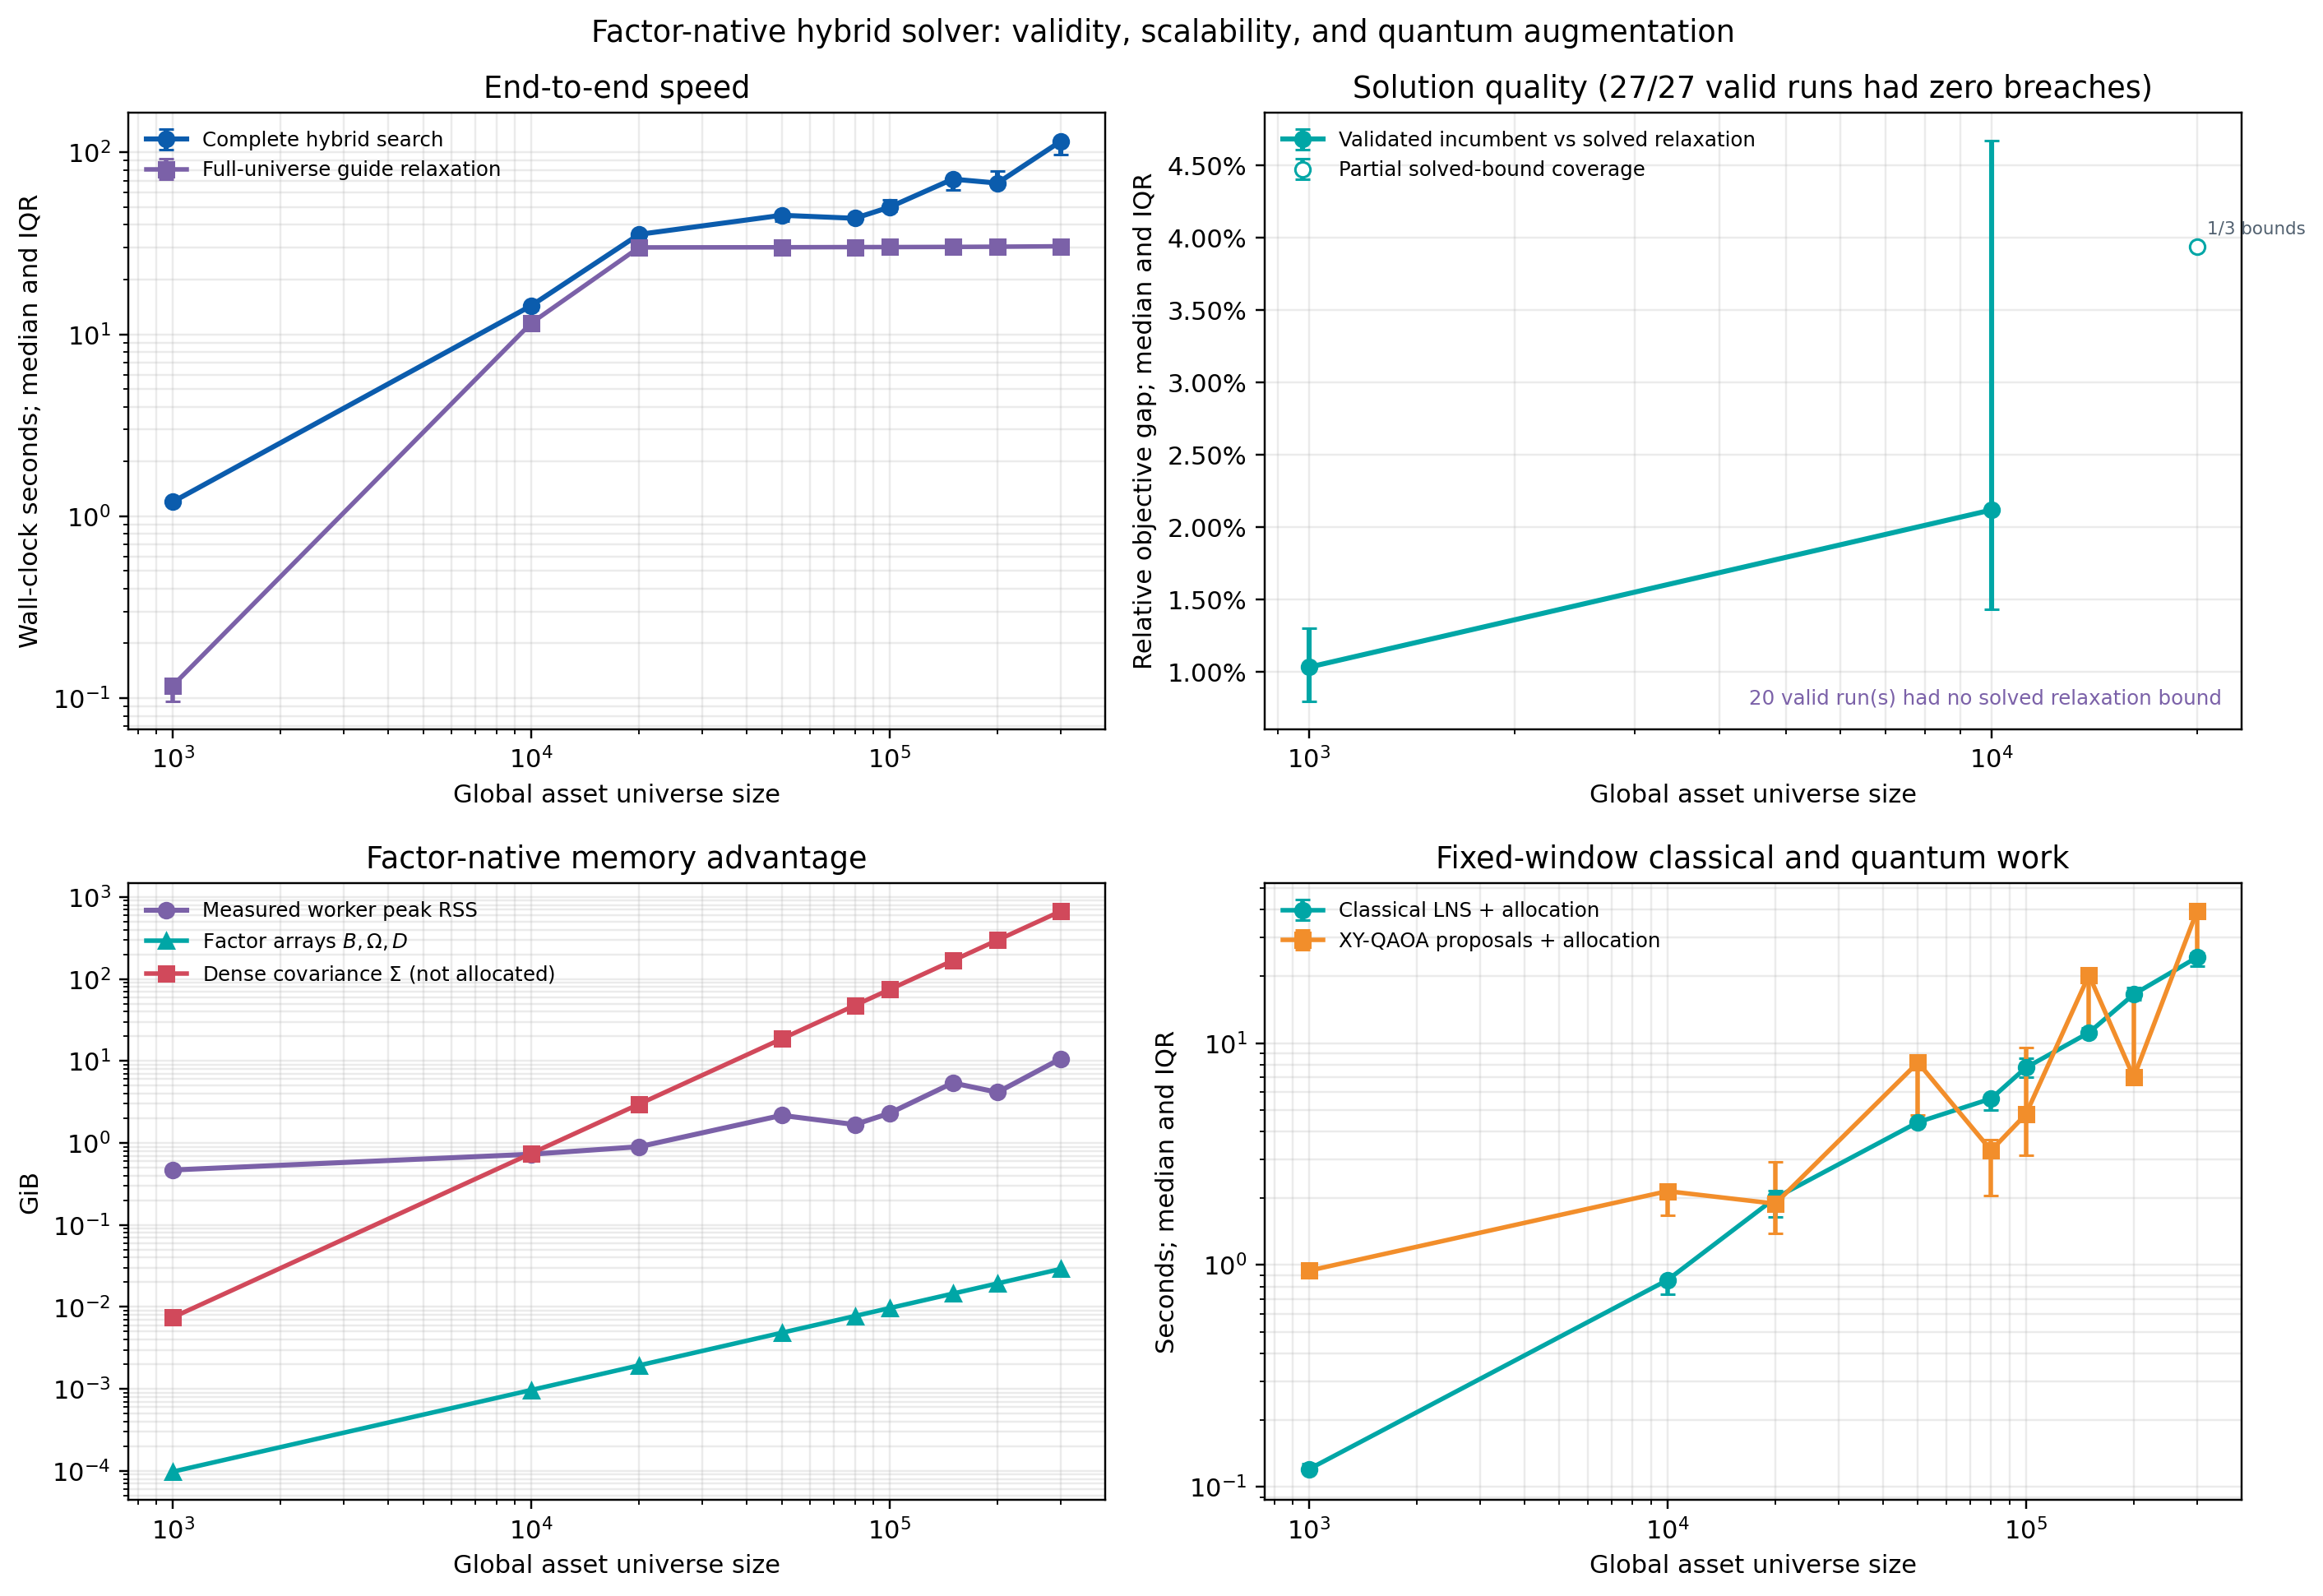

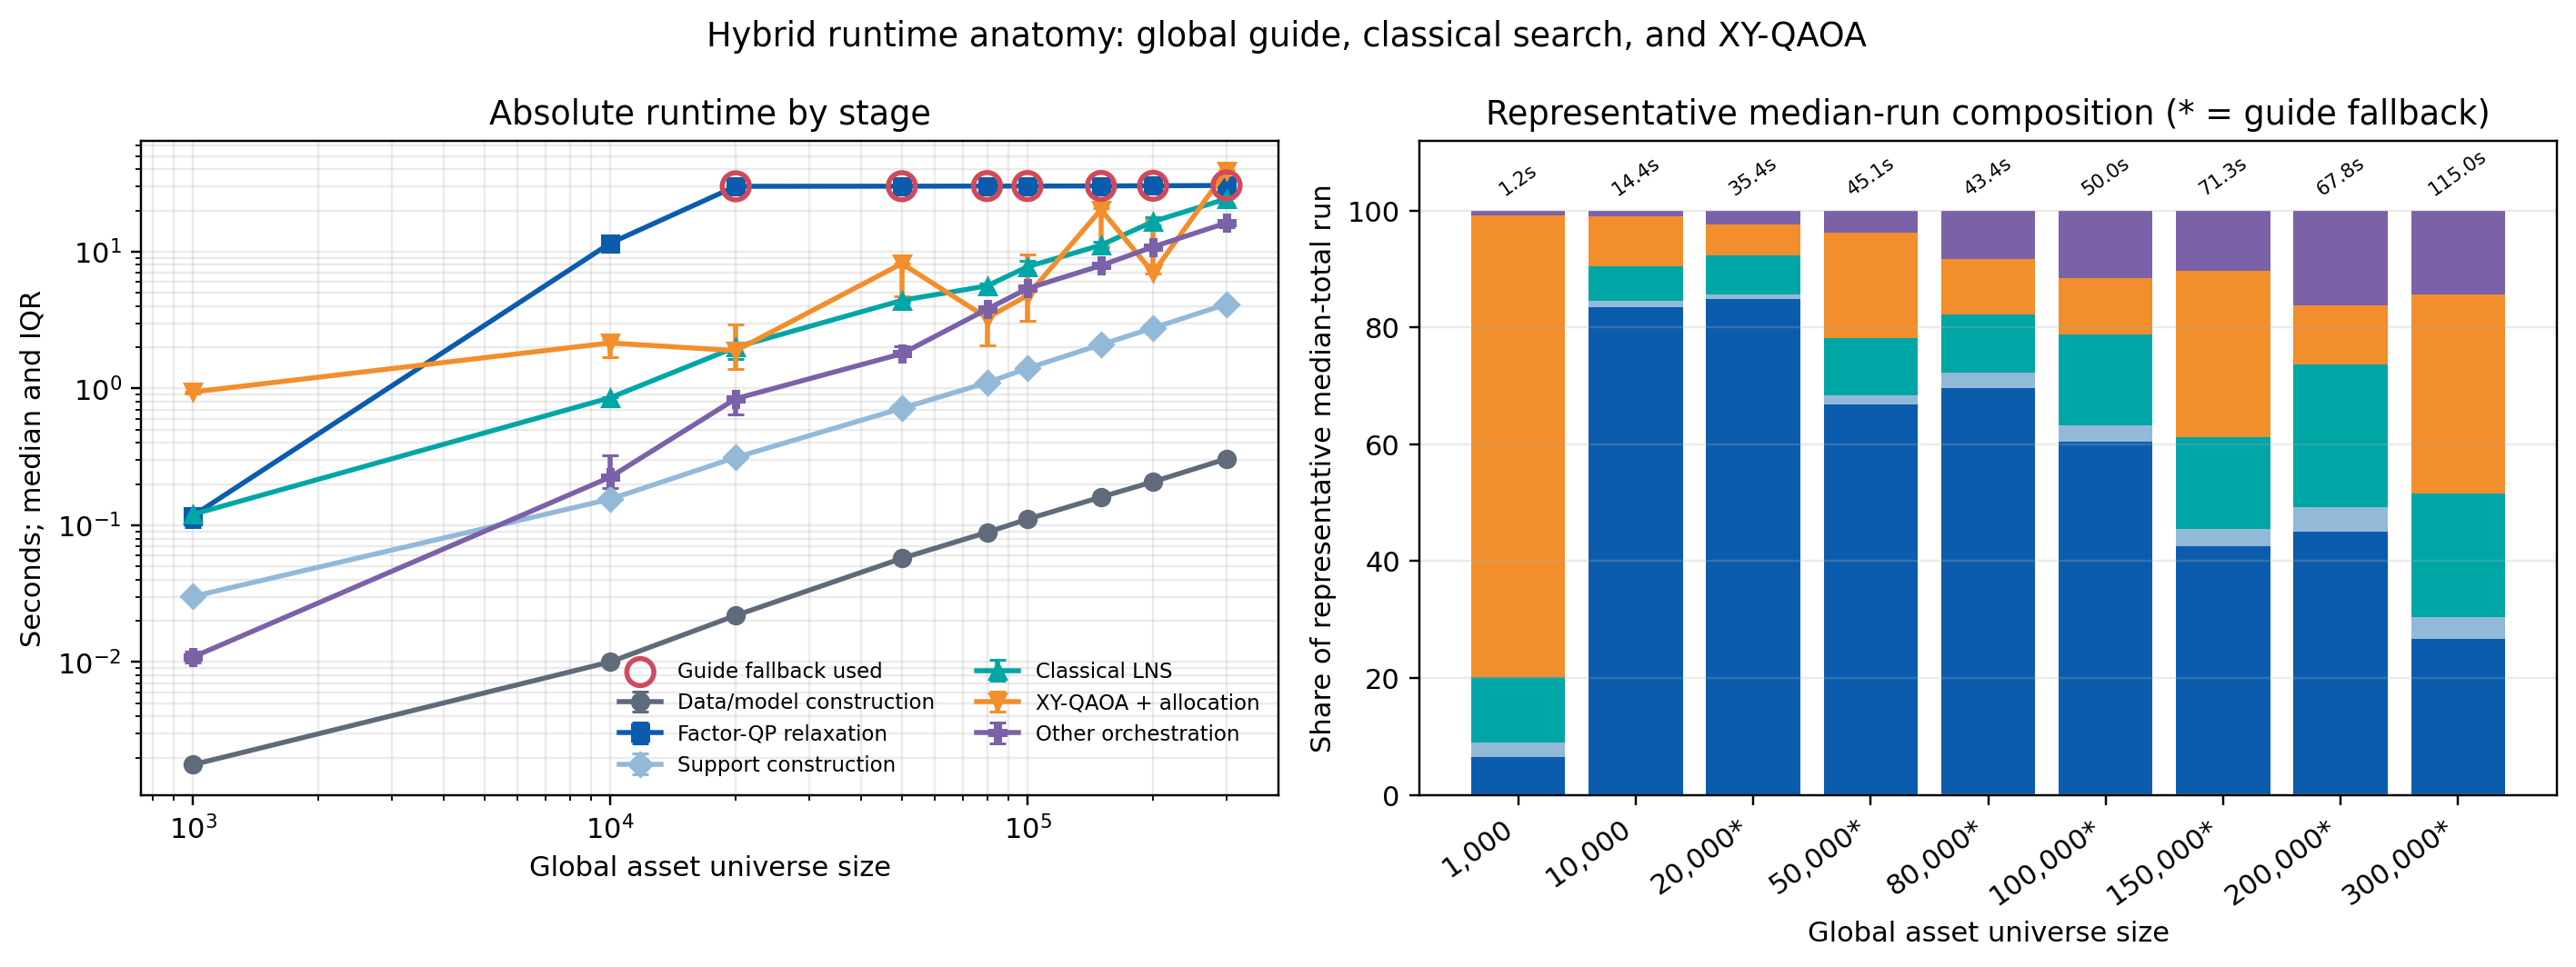

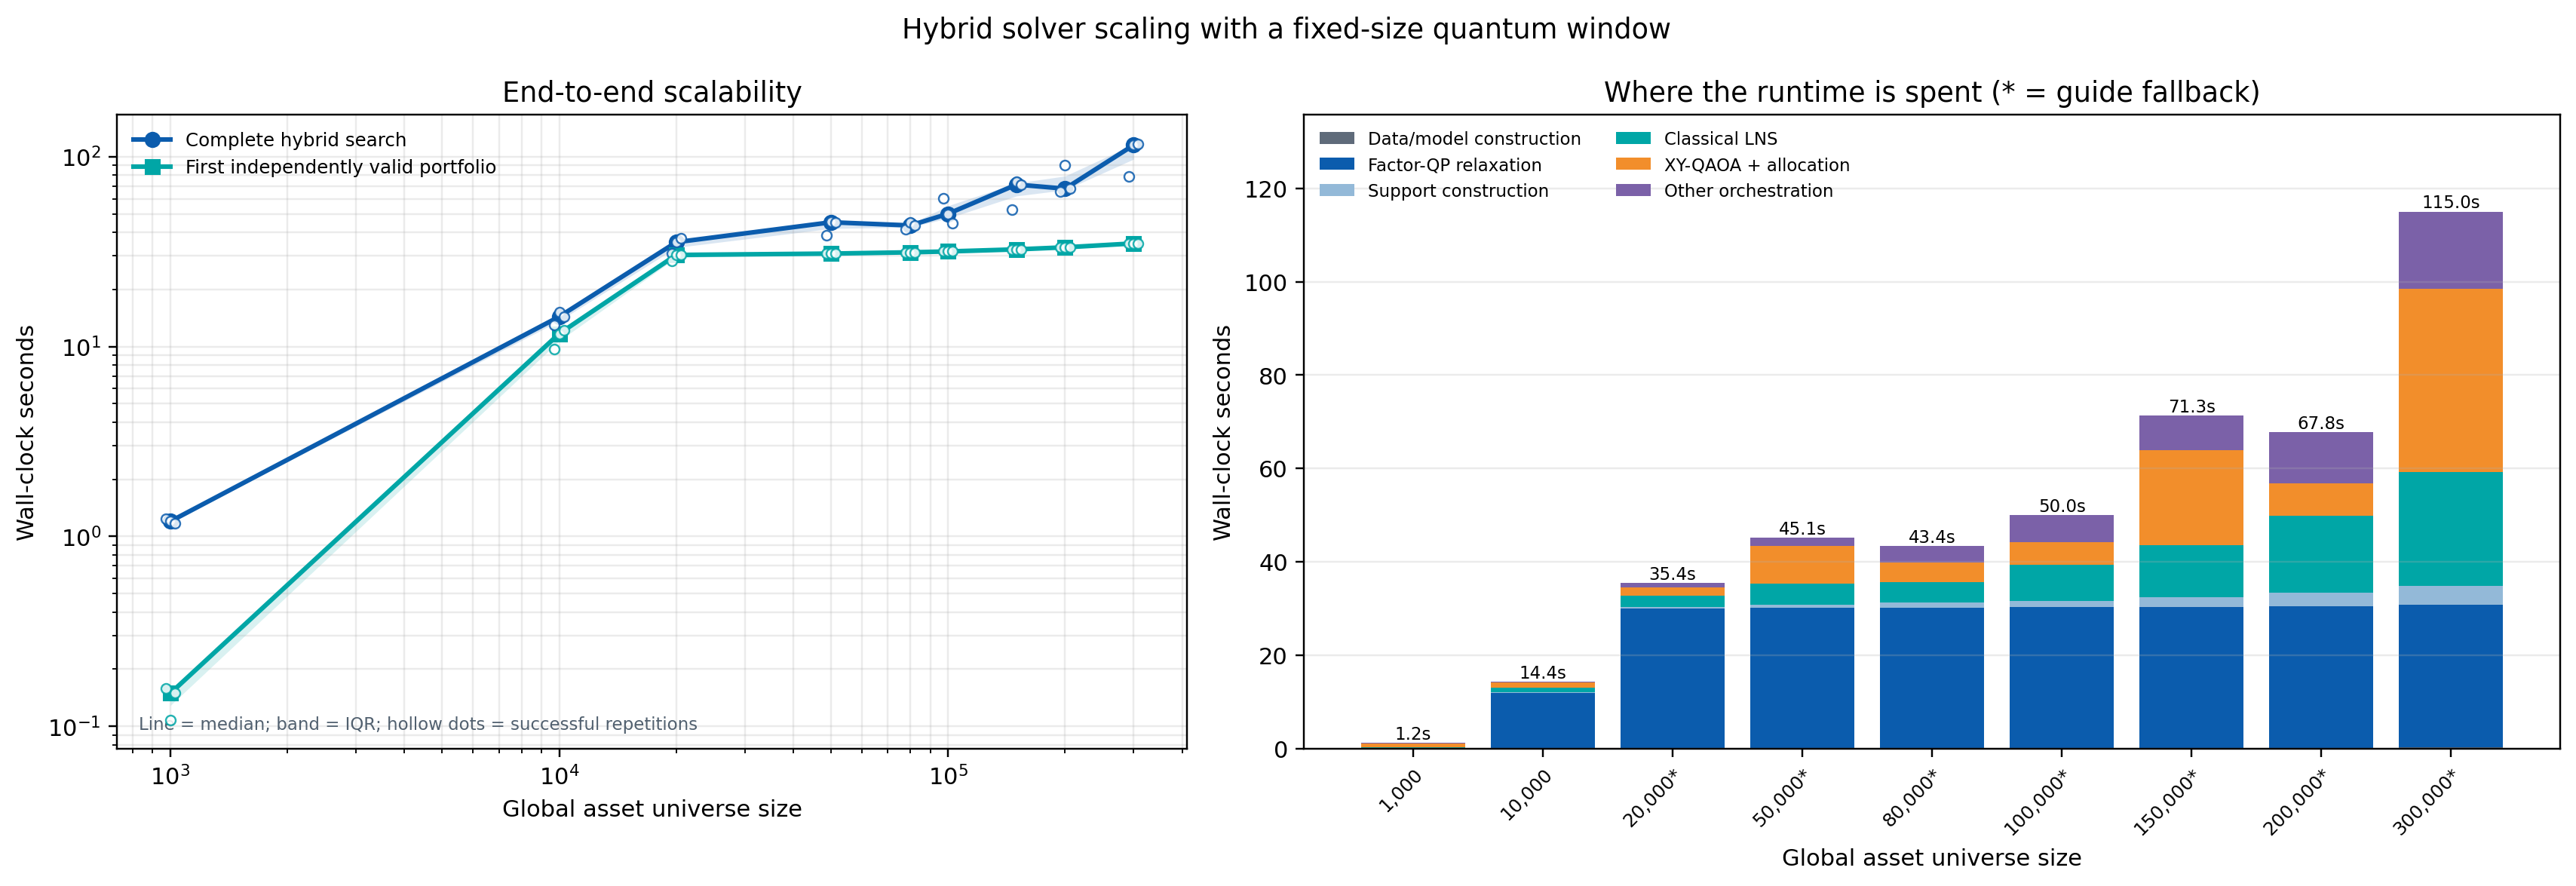

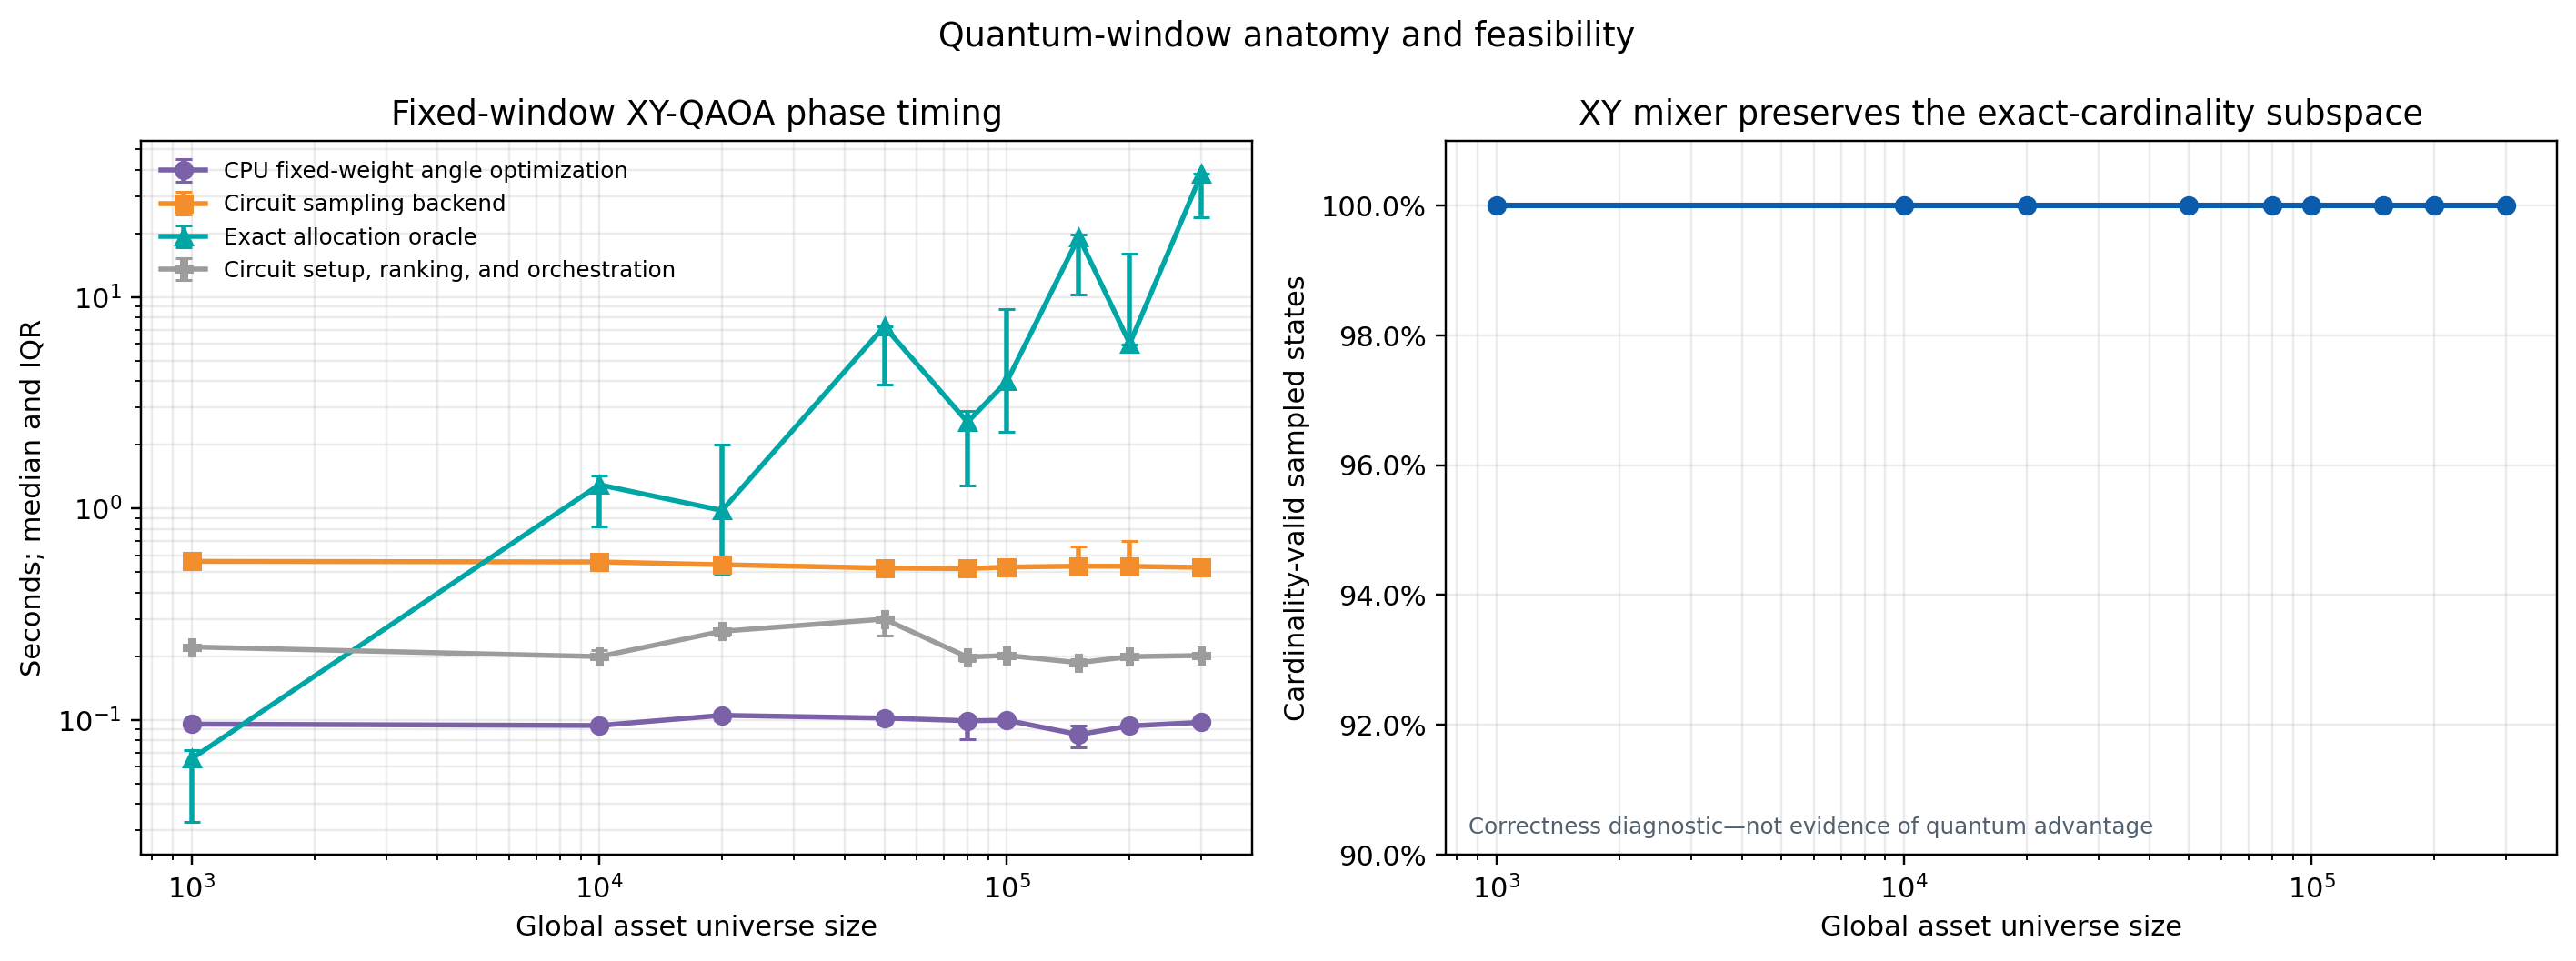

In [17]:
def run_scaling_study(
    *,
    label: str,
    sizes: list[int],
    repetitions: int,
    quantum_backend: str,
) -> tuple[int, Path]:
    output = OUTPUT_ROOT / label
    command = [
        sys.executable,
        str(REPO / "scripts" / "run_hybrid_scaling.py"),
        "--sizes",
        *[str(size) for size in sizes],
        "--repetitions",
        str(repetitions),
        "--cardinality",
        str(SCALING_CARDINALITY),
        "--groups",
        "10",
        "--factors",
        "12",
        "--window-size",
        str(SCALING_WINDOW_SIZE),
        "--iterations",
        "1",
        "--backend",
        ALLOCATION_BACKEND,
        "--relaxation-tolerance",
        str(QP_TOLERANCE),
        "--relaxation-max-iter",
        str(QP_MAX_ITERATIONS),
        "--relaxation-time-limit",
        str(GUIDE_TIME_LIMIT_SECONDS),
        "--allocation-tolerance",
        str(QP_TOLERANCE),
        "--allocation-max-iter",
        str(QP_MAX_ITERATIONS),
        "--case-time-limit",
        str(SCALING_CASE_TIME_LIMIT),
        "--minimum-active-weight",
        "0.005",
        "--maximum-weight",
        "0.04",
        "--max-turnover",
        "0.40",
        "--initial-trials",
        "200",
        "--initial-milp-time-limit",
        "45",
        "--classical-tabu-iterations",
        "30",
        "--classical-tabu-tenure",
        "8",
        "--classical-oracle-candidates",
        "1",
        "--enumerate-windows-up-to",
        "100",
        "--no-gurobi",
        "--certification-max-assets",
        "0",
        "--seed",
        str(BASE_SEED),
        "--allow-failures",
        "--output",
        str(output),
        "--quantum",
        "--quantum-backend",
        quantum_backend,
        "--quantum-depth",
        "1",
        "--quantum-shots",
        str(QAOA_SHOTS),
        "--quantum-optimizer-maxiter",
        str(QAOA_OPTIMIZER_MAXITER),
        "--quantum-optimizer-starts",
        str(QAOA_OPTIMIZER_STARTS),
        "--quantum-top-candidates",
        str(QAOA_TOP_CANDIDATES),
        "--maximum-subspace-states",
        str(QAOA_MAX_SUBSPACE_STATES),
        "--maximum-quantum-edges",
        str(QAOA_MAX_EDGES),
        "--transpile-optimization-level",
        str(TRANSPILE_OPTIMIZATION_LEVEL),
    ]
    command.append(
        "--relaxation-fallback"
        if ALLOW_GUIDE_FALLBACK
        else "--no-relaxation-fallback"
    )
    runs_path = output / "scaling_runs.csv"
    had_checkpoint = runs_path.is_file()
    if had_checkpoint:
        command.append("--resume")

    print(" ".join(command))
    completed = subprocess.run(command, cwd=REPO, check=False)
    if completed.returncode == 3 and had_checkpoint and OVERWRITE_OUTPUTS:
        print(
            "Checkpoint settings or schema changed; rerunning this generated "
            "scaling directory from scratch."
        )
        command = [argument for argument in command if argument != "--resume"]
        command.append("--overwrite")
        print(" ".join(command))
        completed = subprocess.run(command, cwd=REPO, check=False)
    if completed.returncode != 0:
        raise RuntimeError(
            f"Scaling runner exited with code {completed.returncode}; "
            "inspect the messages above before using old checkpoints."
        )
    if not runs_path.is_file():
        raise RuntimeError(f"Scaling study did not write {runs_path}")
    return completed.returncode, output


global_scaling_runs = global_scaling_summary = None
RISK_REPRESENTATION_PROJECTION_SIZES = np.unique(
    np.geomspace(250, 10_000_000, 80).astype(int)
)

if RUN_SCALING_PRESENTATION:
    _, core_output = run_scaling_study(
        label="05_scaling_core_repeated",
        sizes=GLOBAL_CORE_SIZES,
        repetitions=SCALING_REPETITIONS,
        quantum_backend=LOCAL_QUANTUM_BACKEND,
    )
    frames = []
    core_checkpoint_runs = pd.read_csv(core_output / "scaling_runs.csv")
    core_runs = core_checkpoint_runs[
        core_checkpoint_runs["n_assets"].isin(GLOBAL_CORE_SIZES)
        & (pd.to_numeric(core_checkpoint_runs["repetition"], errors="coerce")
           < SCALING_REPETITIONS)
    ].copy()
    core_runs["measurement_tier"] = "repeated core"
    frames.append(core_runs)

    if RUN_SCALING_STRETCH:
        legacy_stretch_runs = core_checkpoint_runs[
            core_checkpoint_runs["n_assets"].isin(GLOBAL_STRETCH_SIZES)
            & (pd.to_numeric(
                core_checkpoint_runs["repetition"], errors="coerce"
            ) < SCALING_STRETCH_REPETITIONS)
            & core_checkpoint_runs["success"].eq(True)
        ].copy()
        completed_legacy_sizes = set(
            pd.to_numeric(legacy_stretch_runs["n_assets"]).astype(int)
        )
        missing_stretch_sizes = [
            size
            for size in GLOBAL_STRETCH_SIZES
            if size not in completed_legacy_sizes
        ]
        stretch_frames = []
        if missing_stretch_sizes:
            _, stretch_output = run_scaling_study(
                label="06_scaling_large_stretch",
                sizes=missing_stretch_sizes,
                repetitions=SCALING_STRETCH_REPETITIONS,
                quantum_backend=LOCAL_QUANTUM_BACKEND,
            )
            stretch_checkpoint_runs = pd.read_csv(
                stretch_output / "scaling_runs.csv"
            )
            stretch_frames.append(
                stretch_checkpoint_runs[
                    stretch_checkpoint_runs["n_assets"].isin(
                        GLOBAL_STRETCH_SIZES
                    )
                    & (pd.to_numeric(
                        stretch_checkpoint_runs["repetition"],
                        errors="coerce",
                    ) < SCALING_STRETCH_REPETITIONS)
                ].copy()
            )
        stretch_frames.append(legacy_stretch_runs)
        stretch_runs = pd.concat(stretch_frames, ignore_index=True)
        stretch_runs = stretch_runs.drop_duplicates(
            ["n_assets", "repetition", "seed"], keep="last"
        )
        stretch_runs["measurement_tier"] = "time-limited stretch"
        frames.append(stretch_runs)

    global_scaling_runs = pd.concat(frames, ignore_index=True)
    successful = global_scaling_runs[global_scaling_runs["success"] == True].copy()
    if successful.empty:
        raise RuntimeError("No successful global scaling cases were produced")
    provenance_columns = {"scaling_schema_version", "case_config_sha256"}
    missing_provenance = provenance_columns - set(successful.columns)
    if missing_provenance:
        raise RuntimeError(
            f"Scaling checkpoints predate provenance validation: "
            f"{sorted(missing_provenance)}. Rerun the scaling cell once."
        )
    if successful["case_config_sha256"].nunique() != 1:
        raise RuntimeError(
            "Scaling checkpoints contain incompatible experiment settings; "
            "use a fresh output directory or allow the notebook to overwrite them."
        )

    summary_rows = []
    for (tier, n_assets), group in global_scaling_runs.groupby(
        ["measurement_tier", "n_assets"], sort=True
    ):
        successful_group = group[group["success"] == True]
        row = {
            "measurement_tier": tier,
            "n_assets": int(n_assets),
            "runs": len(group),
            "successful_runs": len(successful_group),
            "success_rate": len(successful_group) / max(len(group), 1),
            "scaling_schema_version": (
                int(successful_group["scaling_schema_version"].iloc[0])
                if not successful_group.empty else np.nan
            ),
            "case_config_sha256": (
                str(successful_group["case_config_sha256"].iloc[0])
                if not successful_group.empty else ""
            ),
            "failure_reason": " | ".join(
                sorted(
                    {
                        str(value)
                        for value in group.loc[group["success"] != True, "error"].dropna()
                        if str(value).strip()
                    }
                )
            ),
        }
        if successful_group.empty:
            summary_rows.append(row)
            continue
        dense_gib = int(n_assets) ** 2 * np.dtype(np.float64).itemsize / 1024.0**3
        factor_gib = float(successful_group["factor_risk_storage_mib"].median()) / 1024.0
        accepted_gaps = pd.to_numeric(
            successful_group["relative_gap_to_relaxation"], errors="coerce"
        ).dropna()
        row.update(
            {
                "search_seconds_median": float(
                    successful_group["search_end_to_end_seconds"].median()
                ),
                "peak_rss_gib_median": float(successful_group["peak_rss_gib"].median()),
                "factor_risk_gib": factor_gib,
                "dense_covariance_gib": dense_gib,
                "dense_to_factor_ratio": dense_gib / factor_gib,
                "zero_breach_rate": float((successful_group["breaches"] == 0).mean()),
                "relaxation_acceptance_rate": float(
                    successful_group["relaxation_accepted"].mean()
                ),
                "relaxation_bound_rate": float(
                    successful_group["relaxation_bound_available"].mean()
                ),
                "relaxation_bound_runs": int(
                    successful_group["relaxation_bound_available"].sum()
                ),
                "relaxation_fallback_rate": float(
                    successful_group["relaxation_fallback_used"].mean()
                ),
                "relative_gap_to_relaxation_median": (
                    float(accepted_gaps.median()) if not accepted_gaps.empty else np.nan
                ),
                "relaxation_iterations_median": float(
                    successful_group["relaxation_iterations"].median()
                ),
                "relaxation_requested_tolerance": float(
                    successful_group["relaxation_requested_tolerance"].iloc[0]
                ),
                "relaxation_native_tolerance": float(
                    successful_group["relaxation_native_tolerance"].iloc[0]
                ),
            }
        )
        summary_rows.append(row)
    global_scaling_summary = pd.DataFrame(summary_rows).sort_values(
        ["measurement_tier", "n_assets"]
    )
    display(global_scaling_summary)

    combined_output = OUTPUT_ROOT / "05_global_scaling_summary"
    clean_directory(combined_output)
    global_scaling_summary.to_csv(
        combined_output / "global_scaling_summary.csv", index=False
    )

    scaling_plotter_path = REPO / "scripts" / "run_hybrid_scaling.py"
    scaling_plotter_spec = importlib.util.spec_from_file_location(
        "vanguard_scaling_plotter", scaling_plotter_path
    )
    if scaling_plotter_spec is None or scaling_plotter_spec.loader is None:
        raise RuntimeError(f"Could not load {scaling_plotter_path}")
    scaling_plotter = importlib.util.module_from_spec(scaling_plotter_spec)
    scaling_plotter_spec.loader.exec_module(scaling_plotter)
    combined_scaling_records = json.loads(
        global_scaling_runs.to_json(orient="records")
    )
    combined_scaling_plots = scaling_plotter.create_scaling_plots(
        combined_scaling_records, combined_output
    )
    for plot_path in combined_scaling_plots:
        if plot_path.suffix == ".png":
            display(NotebookImage(filename=str(plot_path)))

    factors = 12
    projected_n = RISK_REPRESENTATION_PROJECTION_SIZES.astype(np.float64)
    projection = pd.DataFrame(
        {
            "n_assets": projected_n.astype(np.int64),
            "factor_risk_gib": (
                8.0 * (projected_n * factors + factors**2 + projected_n) / 1024.0**3
            ),
            "dense_covariance_gib": 8.0 * projected_n**2 / 1024.0**3,
        }
    )
    projection["dense_to_factor_ratio"] = (
        projection["dense_covariance_gib"] / projection["factor_risk_gib"]
    )
    projection.to_csv(
        combined_output / "risk_representation_projection.csv", index=False
    )

    figure, axis = plt.subplots(figsize=(8.4, 5.4))
    axis.plot(
        projection["n_assets"],
        projection["factor_risk_gib"],
        linewidth=2.2,
        color="#00A6A6",
        label=r"Factor representation $B,\Omega,D$",
    )
    axis.plot(
        projection["n_assets"],
        projection["dense_covariance_gib"],
        linewidth=2.2,
        color="#D1495B",
        label=r"Dense covariance $\Sigma$",
    )
    measured_rows = global_scaling_summary[
        global_scaling_summary["successful_runs"] > 0
    ]
    axis.scatter(
        measured_rows["n_assets"],
        measured_rows["factor_risk_gib"],
        color="#0B5CAD",
        s=35,
        zorder=3,
        label="Measured factor-array bytes",
    )
    measured_maximum = int(measured_rows["n_assets"].max())
    axis.axvline(measured_maximum, color="black", linestyle=":", linewidth=1.0)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Asset universe size")
    axis.set_ylabel("GiB")
    axis.set_title("Risk storage: measured factor arrays and analytical projection")
    axis.grid(alpha=0.25, which="both")
    axis.legend(frameon=False)
    figure.tight_layout()
    for suffix in ("png", "pdf"):
        figure.savefig(
            combined_output / f"factor_vs_dense_memory.{suffix}",
            dpi=220 if suffix == "png" else None,
            bbox_inches="tight",
        )
    plt.show()


## 11. IBM QPU hardware-validation experiment

**Experiment.** Reuses CPU-optimized XY-QAOA angles on selected IBM hardware,
saves every job immediately, and compares cardinality rate, validated portfolio
improvement, transpiled two-qubit gates, QPU usage, and queue-inclusive wall
time. 

**Importance.** This demonstrates real-hardware readiness while
keeping the global classical solve and the small QPU window conceptually clear.

Hardware execution is off by default because credentials and allocation are
user-specific. If no account is configured, the cell prints the one-time setup
and returns cleanly so all following cells still run.


In [ ]:
qpu_results = None
qpu_errors = []
qpu_output_path = OUTPUT_ROOT / "ibm_qpu_hardware_validation.csv"


def _qpu_row_key(row: dict[str, object]) -> tuple[str, int, int, int]:
    return (
        str(row["backend"]),
        int(row["width"]),
        int(row["depth"]),
        int(row["repetition"]),
    )


def _save_qpu_row(
    rows: list[dict[str, object]],
    row: dict[str, object],
) -> None:
    key = _qpu_row_key(row)
    for index, existing in enumerate(rows):
        if _qpu_row_key(existing) == key:
            rows[index] = row
            break
    else:
        rows.append(row)
    pd.DataFrame(rows).to_csv(qpu_output_path, index=False)


def _execute_ibm_qpu_experiment() -> tuple[pd.DataFrame, list[dict[str, object]]]:
    from importlib import metadata as package_metadata

    try:
        from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    except Exception as exc:
        raise RuntimeError(
            "IBM Runtime is unavailable in this notebook kernel. Run "
            f"{sys.executable} -m pip install -e '.[full]', restart the "
            "kernel, and rerun the environment preflight."
        ) from exc

    quantum_versions = {
        name: package_metadata.version(name)
        for name in ("qiskit", "qiskit-ibm-runtime")
    }
    if quantum_versions != {
        "qiskit": "2.5.1",
        "qiskit-ibm-runtime": "0.48.0",
    }:
        raise RuntimeError(
            f"Unexpected quantum package versions: {quantum_versions}. "
            "Run scripts/install_environment.py and restart this kernel."
        )
    assert SamplerV2 is not None

    try:
        service = QiskitRuntimeService()
    except Exception as exc:
        raise RuntimeError(
            "IBM Runtime is installed, but no usable default account was "
            "found. Save the account once with "
            "QiskitRuntimeService.save_account(channel="
            "'ibm_quantum_platform', token=..., set_as_default=True), "
            "then rerun this cell."
        ) from exc

    required_qubits = max(QPU_WIDTHS)
    try:
        if IBM_BACKEND_NAME:
            selected_backend = service.backend(IBM_BACKEND_NAME)
        else:
            selected_backend = service.least_busy(
                operational=True,
                simulator=False,
                min_num_qubits=required_qubits,
                use_fractional_gates=False,
            )
    except Exception as exc:
        raise RuntimeError(
            f"No accessible operational IBM backend has {required_qubits} "
            f"qubits for the active account: {exc}"
        ) from exc

    backend_name_value = getattr(selected_backend, "name", "")
    selected_backend_name = (
        str(backend_name_value())
        if callable(backend_name_value)
        else str(backend_name_value)
    )
    backend_qubits = int(getattr(selected_backend, "num_qubits", 0))
    backend_status = selected_backend.status()
    if not bool(getattr(backend_status, "operational", False)):
        raise RuntimeError(
            f"Selected backend {selected_backend_name!r} is not operational: "
            f"{getattr(backend_status, 'status_msg', 'unknown status')}"
        )
    if backend_qubits < required_qubits:
        raise RuntimeError(
            f"Selected backend {selected_backend_name!r} has "
            f"{backend_qubits} qubits; {required_qubits} are required."
        )

    print("IBM Runtime channel:", getattr(service, "channel", "unknown"))
    print("IBM backend:", selected_backend_name)
    print("Backend qubits:", backend_qubits)
    print("Pending jobs at selection:", getattr(backend_status, "pending_jobs", "unknown"))

    rows: list[dict[str, object]] = []
    if QPU_RESUME and qpu_output_path.is_file():
        previous = pd.read_csv(qpu_output_path)
        rows = previous.to_dict(orient="records")
        for row in rows:
            if "status" not in row or pd.isna(row["status"]):
                row["status"] = "success"
        print(f"Loaded {len(rows)} checkpoint rows from {qpu_output_path}")

    completed = {
        _qpu_row_key(row)
        for row in rows
        if str(row.get("status", "")) == "success"
    }

    for width in QPU_WIDTHS:
        bundle = make_window_bundle(
            frozen_base,
            width,
            maximum_edges=QPU_MAX_EDGES,
        )
        qubo = bundle["qubo"]
        window = bundle["window"]
        initial_bits = bundle["initial_bits"]
        state_count = comb(qubo.n, qubo.required_ones)
        exact = exact_qubo_top_states(qubo)
        exact_energy = None if exact is None else exact["best_energy"]

        for depth in QPU_DEPTHS:
            cpu_config = XYQAOAConfig(
                depth=depth,
                shots=QPU_SHOTS,
                optimizer_maxiter=QPU_OPTIMIZER_MAXITER,
                optimizer_starts=QPU_OPTIMIZER_STARTS,
                seed=BASE_SEED + 700 + 10 * width + depth,
                initial_state="warm",
                mixer="ring",
                backend="subspace",
                maximum_subspace_states=max(
                    QAOA_MAX_SUBSPACE_STATES,
                    state_count,
                ),
                top_candidates=QAOA_TOP_CANDIDATES,
                transpile_optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
            )
            ideal = solve_xy_qaoa(qubo, initial_bits, cpu_config)
            cpu_key = ("exact_subspace_cpu", width, depth, 0)
            if cpu_key not in completed:
                ideal_oracle = new_oracle(bundle)
                ideal_allocated = evaluate_bitstrings(
                    ideal.method,
                    qubo,
                    [initial_bits.copy(), *ideal.bitstrings],
                    ideal_oracle,
                    window.frozen_support,
                )
                _save_qpu_row(
                    rows,
                    {
                        "status": "success",
                        "error": "",
                        "backend": "exact_subspace_cpu",
                        "width": width,
                        "required_ones": qubo.required_ones,
                        "depth": depth,
                        "repetition": 0,
                        "shots": QPU_SHOTS,
                        "job_id": "",
                        "calibration_timestamp": "",
                        "state_count": state_count,
                        "exact_qubo_energy": exact_energy,
                        "best_sampled_energy": ideal.best_sampled_energy,
                        "energy_regret": (
                            np.nan
                            if exact_energy is None
                            else ideal.best_sampled_energy - exact_energy
                        ),
                        "cardinality_rate": ideal.cardinality_feasibility_rate,
                        "unique_bitstrings": ideal.metadata[
                            "unique_sampled_bitstrings"
                        ],
                        "validated_objective": ideal_allocated.best.objective,
                        "objective_improvement": (
                            float(bundle["initial"].objective)
                            - float(ideal_allocated.best.objective)
                        ),
                        "transpiled_depth": np.nan,
                        "two_qubit_gates": ideal.metadata[
                            "logical_two_qubit_gates"
                        ],
                        "qpu_usage_seconds": np.nan,
                        "qpu_wall_seconds": np.nan,
                    },
                )
                completed.add(cpu_key)

            for repetition in range(1, QPU_REPETITIONS + 1):
                hardware_key = (
                    selected_backend_name,
                    width,
                    depth,
                    repetition,
                )
                if hardware_key in completed:
                    print("Skipping completed QPU job:", hardware_key)
                    continue

                try:
                    qpu_config = replace(
                        cpu_config,
                        backend="ibm_runtime",
                        ibm_backend=selected_backend_name,
                    )
                    qpu = solve_xy_qaoa(qubo, initial_bits, qpu_config)
                    if not np.allclose(ideal.angles, qpu.angles):
                        raise RuntimeError(
                            "CPU and QPU paths did not reuse identical angles"
                        )

                    qpu_oracle = new_oracle(bundle)
                    qpu_allocated = evaluate_bitstrings(
                        qpu.method,
                        qubo,
                        [initial_bits.copy(), *qpu.bitstrings],
                        qpu_oracle,
                        window.frozen_support,
                    )
                    row = {
                        "status": "success",
                        "error": "",
                        "backend": selected_backend_name,
                        "width": width,
                        "required_ones": qubo.required_ones,
                        "depth": depth,
                        "repetition": repetition,
                        "shots": QPU_SHOTS,
                        "job_id": qpu.metadata.get("job_id", ""),
                        "calibration_timestamp": qpu.metadata.get(
                            "backend_calibration_timestamp",
                            "",
                        ),
                        "state_count": state_count,
                        "exact_qubo_energy": exact_energy,
                        "best_sampled_energy": qpu.best_sampled_energy,
                        "energy_regret": (
                            np.nan
                            if exact_energy is None
                            else qpu.best_sampled_energy - exact_energy
                        ),
                        "cardinality_rate": qpu.cardinality_feasibility_rate,
                        "unique_bitstrings": qpu.metadata[
                            "unique_sampled_bitstrings"
                        ],
                        "validated_objective": qpu_allocated.best.objective,
                        "objective_improvement": (
                            float(bundle["initial"].objective)
                            - float(qpu_allocated.best.objective)
                        ),
                        "transpiled_depth": qpu.metadata.get(
                            "transpiled_depth"
                        ),
                        "two_qubit_gates": qpu.metadata.get(
                            "transpiled_two_qubit_gates"
                        ),
                        "qpu_usage_seconds": qpu.metadata.get(
                            "qpu_usage_seconds"
                        ),
                        "qpu_wall_seconds": qpu.metadata.get(
                            "qpu_wall_seconds"
                        ),
                    }
                    _save_qpu_row(rows, row)
                    completed.add(hardware_key)
                    print(
                        "Completed",
                        hardware_key,
                        "job_id=",
                        row["job_id"],
                    )
                except Exception as exc:
                    error = f"{type(exc).__name__}: {exc}"
                    qpu_errors.append(
                        {
                            "backend": selected_backend_name,
                            "width": width,
                            "depth": depth,
                            "repetition": repetition,
                            "error": error,
                        }
                    )
                    _save_qpu_row(
                        rows,
                        {
                            "status": "failed",
                            "error": error,
                            "backend": selected_backend_name,
                            "width": width,
                            "required_ones": qubo.required_ones,
                            "depth": depth,
                            "repetition": repetition,
                            "shots": QPU_SHOTS,
                            "job_id": "",
                            "calibration_timestamp": "",
                            "state_count": state_count,
                            "exact_qubo_energy": exact_energy,
                        },
                    )
                    print("QPU job failed:", hardware_key, error)
                    if QPU_FAIL_FAST:
                        raise

    qpu_results = pd.DataFrame(rows)
    if not qpu_results.empty:
        qpu_results = qpu_results.sort_values(
            ["backend", "width", "depth", "repetition"],
            ignore_index=True,
        )
        qpu_results.to_csv(qpu_output_path, index=False)
    display(qpu_results)
    if qpu_errors:
        display(pd.DataFrame(qpu_errors))

    successful = qpu_results[
        qpu_results["status"].astype(str) == "success"
    ].copy()
    hardware = successful[
        successful["backend"] != "exact_subspace_cpu"
    ].copy()

    if hardware.empty:
        print("No successful IBM hardware rows are available to plot yet.")
    else:
        figure, axes = plt.subplots(2, 2, figsize=(15, 10))
        for (backend, depth), group in successful.groupby(
            ["backend", "depth"]
        ):
            aggregate = group.groupby(
                "width",
                as_index=False,
            ).median(numeric_only=True)
            label = f"{backend}, p={int(depth)}"
            axes[0, 0].plot(
                aggregate["width"],
                aggregate["cardinality_rate"],
                marker="o",
                label=label,
            )
            axes[0, 1].plot(
                aggregate["width"],
                aggregate["objective_improvement"],
                marker="o",
                label=label,
            )

        for depth, group in hardware.groupby("depth"):
            aggregate = group.groupby(
                "width",
                as_index=False,
            ).median(numeric_only=True)
            axes[1, 0].plot(
                aggregate["width"],
                aggregate["two_qubit_gates"],
                marker="o",
                label=f"p={int(depth)}",
            )
            axes[1, 1].plot(
                aggregate["width"],
                aggregate["qpu_wall_seconds"],
                marker="o",
                label=f"wall, p={int(depth)}",
            )
            if aggregate["qpu_usage_seconds"].notna().any():
                axes[1, 1].plot(
                    aggregate["width"],
                    aggregate["qpu_usage_seconds"],
                    marker="s",
                    linestyle="--",
                    label=f"QPU usage, p={int(depth)}",
                )

        axes[0, 0].set_title("Raw fixed-cardinality shot rate")
        axes[0, 0].set_ylabel("Rate")
        axes[0, 0].set_ylim(0.0, 1.02)
        axes[0, 1].set_title("Validated portfolio improvement")
        axes[0, 1].set_ylabel("Improvement over warm start")
        axes[1, 0].set_title("Hardware circuit burden")
        axes[1, 0].set_ylabel("Transpiled two-qubit gates")
        axes[1, 1].set_title("QPU time")
        axes[1, 1].set_ylabel("Seconds")
        for axis in axes.flat:
            axis.set_xlabel("Qubits / window width")
            axis.legend(fontsize=8)
            axis.grid(alpha=0.25)

        figure.tight_layout()
        for suffix in ("png", "pdf"):
            figure.savefig(
                OUTPUT_ROOT / f"ibm_qpu_hardware_validation.{suffix}",
                dpi=220,
                bbox_inches="tight",
            )
        plt.show()


    return qpu_results, qpu_errors


if RUN_IBM_QPU:
    try:
        qpu_results, qpu_errors = _execute_ibm_qpu_experiment()
    except Exception as exc:
        message = f"{type(exc).__name__}: {exc}"
        qpu_errors = [{"stage": "preflight", "error": message}]
        print("IBM QPU experiment was not started:", message)
        print(
            "One-time setup (never commit the token):\n"
            "from getpass import getpass\n"
            "from qiskit_ibm_runtime import QiskitRuntimeService\n"
            "QiskitRuntimeService.save_account(" 
            "channel='ibm_quantum_platform', token=getpass('IBM token: '), "
            "overwrite=True, set_as_default=True)"
        )
        if QPU_FAIL_FAST:
            raise
else:
    if QPU_RESUME and qpu_output_path.is_file():
        qpu_results = pd.read_csv(qpu_output_path)
        print(f"Loaded {len(qpu_results)} prior QPU checkpoint rows.")
    else:
        qpu_results = pd.DataFrame()
    print(
        "IBM hardware run skipped. Set RUN_IBM_QPU=True after saving an IBM "
        "Runtime account; all local CPU/GPU/XY-QAOA experiments are complete."
    )


IBM Runtime channel: ibm_quantum_platform
IBM backend: ibm_fez
Backend qubits: 156
Pending jobs at selection: 41
Loaded 4 checkpoint rows from /mnt/Home/apomorov/Wiser/vanguard-multi-asset-portfolio/results/presentation_benchmark_suite/ibm_qpu_hardware_validation.csv
Skipping completed QPU job: ('ibm_fez', 8, 1, 1)
Skipping completed QPU job: ('ibm_fez', 8, 1, 2)


## 12. Optional appendix — legacy quantum formulations

This section shows that the study considered a broader range of quantum optimization approaches before selecting fixed-cardinality XY-QAOA as the main experimental path. The earlier VQE- and PCE-based models are retained as alternative formulations so their assumptions, qubit requirements, constraint handling, and practical limitations can be compared with the final method.

They are disabled by default because they are not part of the primary evidence chain used for the reported hybrid results. The central experiments use XY-QAOA because it works directly within a fixed-cardinality subspace, aligns with the portfolio holding-count constraint, and integrates naturally with the classical allocation oracle and independent validator.

The purpose of keeping the VQE/PCE alternatives is therefore not to present them as competing production solvers, but to demonstrate the breadth of the investigation and explain why the final architecture was chosen. Their inclusion documents that multiple quantum formulations were explored, evaluated, and narrowed to the approach most appropriate for the constrained portfolio problem.


In [ ]:
if RUN_LEGACY_ALTERNATIVE_MODELS:
    legacy_commands = [
        [
            sys.executable,
            str(REPO / "scripts" / "run_quantum.py"),
            "--n-lots",
            "20",
            "--n-restarts",
            "5",
            "--reps",
            "8",
            "--seed",
            str(BASE_SEED),
        ],
        [
            sys.executable,
            str(REPO / "scripts" / "run_quantum_vqe.py"),
        ],
        [
            sys.executable,
            str(REPO / "scripts" / "run_vqe_pce.py"),
        ],
        [
            sys.executable,
            str(REPO / "scripts" / "compare_all.py"),
            str(
                REPO
                / "data"
                / "synthetic"
                / "synthetic_universe.json"
            ),
        ],
    ]
    for command in legacy_commands:
        print("\nRUNNING:", " ".join(command))
        subprocess.run(command, cwd=REPO, check=False)

## 13. Optional Copilot launch

This cell prints the command for the interactive decision-support interface.
It is separated from numerical experiments so launching a web process cannot
interfere with benchmark timing.


In [ ]:
def copilot_command() -> list[str]:
    return [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        str(
            REPO
            / "src"
            / "vanguard_portfolio"
            / "copilot_app.py"
        ),
    ]

print("Copilot command:")
print(" ".join(copilot_command()))

## 14. Generate evidence-backed presentation claims

**Experiment.** Writes only claims supported by results produced in this run.


**Importance.** Certified MIQP gaps, continuous-relaxation gaps, GPU
execution, QPU jobs, and zero-breach validation remain explicitly distinct.


In [ ]:
claim_lines = [
    "# Evidence-backed presentation claims",
    "",
    (
        f"- Repository commit: `{environment['commit']}` "
        f"on branch `{environment['branch']}`."
    ),
]


if continuous_backend_crosscheck is not None:
    successful_backends = continuous_backend_crosscheck[
        continuous_backend_crosscheck["success"] == True
    ]
    if len(successful_backends) >= 2:
        spread = (
            successful_backends["objective"].max()
            - successful_backends["objective"].min()
        )
        claim_lines.append(
            f"- {len(successful_backends)} independent continuous-QP "
            f"backends agreed within an objective spread of {spread:.3e}."
        )

if tiny_run is not None:
    claim_lines.append(
        f"- Tiny exact-certification case completed with "
        f"{tiny_run.best.breaches} hard-constraint breaches."
    )
    tiny_gurobi = tiny_frame[
        tiny_frame["method"] == "gurobi_cardinality_miqp"
    ]
    tiny_enum = tiny_frame[
        tiny_frame["method"] == "classical_enumeration"
    ]
    if not tiny_gurobi.empty and not tiny_enum.empty:
        spread = abs(
            float(tiny_gurobi.iloc[-1]["objective"])
            - float(tiny_enum.iloc[-1]["objective"])
        )
        claim_lines.append(
            f"- Tiny enumeration and Gurobi objectives differ by "
            f"{spread:.3e}."
        )

if main_run is not None:
    claim_lines.append(
        f"- The 100-asset canonical hybrid case returned "
        f"{np.count_nonzero(main_run.best.weights > 1e-8)} "
        f"holdings with {main_run.best.breaches} "
        "hard-constraint breaches."
    )
    gurobi_rows = main_frame[
        main_frame["method"] == "gurobi_cardinality_miqp"
    ]
    if not gurobi_rows.empty:
        row = gurobi_rows.iloc[-1]
        gap = row.get("reported_mip_gap")
        if pd.notna(gap):
            claim_lines.append(
                f"- Gurobi reported a MIP gap of "
                f"{float(gap):.4%} for the 100-asset reference."
            )


if gurobi_start_study is not None:
    fastest = gurobi_start_study.loc[
        gurobi_start_study["total_seconds"].idxmin()
    ]
    claim_lines.append(
        f"- In the controlled Gurobi start study, "
        f"`{fastest['start']}` was fastest at "
        f"{float(fastest['total_seconds']):.3f} s; "
        "cold and warm starts are reported separately."
    )

if backtest_robustness_summary is not None:
    claim_lines.append(
        f"- Out-of-sample behavior was evaluated across "
        f"{BACKTEST_ROBUSTNESS_PATHS} independent synthetic paths, "
        "with medians and 10th–90th percentile ranges reported."
    )

if gauntlet_run is not None:
    claim_lines.append(
        "- One constraint-gauntlet case simultaneously enforced "
        "exact cardinality, minimum/maximum positions, eligibility, "
        "mandatory assets, group limits, turnover, target return, "
        "minimum income, factor bands, stress floors, and empirical CVaR."
    )
    claim_lines.append(
        f"- The all-constraints portfolio had "
        f"{gauntlet_run.best.breaches} independently recomputed breaches."
    )

if frozen_benchmark is not None:
    best_row = frozen_benchmark.iloc[0]
    claim_lines.append(
        f"- On the frozen {FROZEN_WINDOW_WIDTH}-asset window, "
        f"the best tested method was `{best_row['method']}` "
        f"with validated improvement "
        f"{float(best_row['objective_improvement']):.6g} "
        "over the warm start."
    )
    gpu_rows = frozen_benchmark[
        frozen_benchmark["method"].astype(str).str.contains(
            "aer_gpu"
        )
    ]
    if (
        not gpu_rows.empty
        and bool(gpu_rows.iloc[0].get("gpu_accelerated", False))
    ):
        claim_lines.append(
            "- Aer execution metadata verified GPU sampling "
            "for the frozen-window circuit."
        )

if global_scaling_runs is not None:
    successful = global_scaling_runs[
        global_scaling_runs["success"] == True
    ].copy()
    if not successful.empty:
        maximum_size = int(successful["n_assets"].max())
        maximum_rows = successful[successful["n_assets"] == maximum_size]
        claim_lines.append(
            f"- The largest successful measured factor-native universe "
            f"contained {maximum_size:,} assets."
        )
        claim_lines.append(
            f"- At {maximum_size:,} assets, median time to the first valid "
            f"portfolio was {maximum_rows['time_to_first_valid_seconds'].median():.3f} s "
            f"and median complete hybrid search time was "
            f"{maximum_rows['search_end_to_end_seconds'].median():.3f} s."
        )
        claim_lines.append(
            f"- Across recorded scaling trials, "
            f"{int((successful['breaches'] == 0).sum())}/{len(successful)} "
            "successful runs had zero breaches."
        )

if qpu_results is not None and not qpu_results.empty:
    hardware = qpu_results[
        (qpu_results["backend"] != "exact_subspace_cpu")
        & (qpu_results["status"].astype(str) == "success")
        & qpu_results["job_id"].fillna("").astype(str).ne("")
    ].copy()
    if not hardware.empty:
        claim_lines.append(
            f"- IBM Runtime hardware evidence contains "
            f"{hardware['job_id'].nunique()} distinct successful job IDs."
        )
        claim_lines.append(
            f"- Median raw QPU fixed-cardinality rate was "
            f"{hardware['cardinality_rate'].median():.2%}."
        )
        feasible_improvements = hardware[
            "objective_improvement"
        ].dropna()
        if not feasible_improvements.empty:
            claim_lines.append(
                f"- Best QPU-generated validated improvement over "
                f"the warm start was "
                f"{feasible_improvements.max():.6g}."
            )
    else:
        claim_lines.append(
            "- No successful IBM hardware job with a non-empty job ID was "
            "available; no QPU-performance claim was generated."
        )

claim_lines.extend(
    [
        "",
        "## Required interpretation limits",
        "",
        (
            "- Global asset count is not QPU width; the QPU receives "
            "only the adaptive window."
        ),
        (
            "- A continuous-relaxation gap is not a certified "
            "mixed-integer optimality gap."
        ),
        (
            "- Cardinality preservation demonstrates circuit correctness, "
            "not quantum advantage."
        ),
        (
            "- QPU queue-inclusive wall time and QPU usage time must be "
            "reported separately."
        ),
        "- Synthetic backtests are demonstrations, not investment forecasts.",
    ]
)

claims_path = OUTPUT_ROOT / "winning_claims.md"
claims_path.write_text(
    "\n".join(claim_lines) + "\n",
    encoding="utf-8",
)
print(claims_path.read_text(encoding="utf-8"))

## 15. Overview

### Main deck

1. Hybrid architecture: global factor QP, adaptive window, classical/XY-QAOA
   proposals, exact allocation, independent validation.
2. Tiny enumeration/Gurobi correctness certificate.
3. Canonical 100-asset objective/runtime and key-guardrail panel.
4. All-constraints headroom certificate, market-community heatmap, and the
   four-panel sparse-CVaR scaling dashboard.
5. Frozen-window candidate-efficiency plot highlighting XY-QAOA's role.
6. Global scaling evidence: the headline validity/speed/memory dashboard,
   the main-deck runtime overview, detailed per-universe composition, and
   XY-QAOA phase/cardinality timing.
7. IBM hardware panel only when successful job IDs exist.

### Appendix

- complete constraint checks and optional ablation;
- width/depth/QUBO-regret details;
- multi-seed synthetic robustness;
- environment and package manifest;
- limitations, including the explicit no-quantum-advantage statement.
